# Práctica 04 : Análisis de datos exploratorio con python y jupiter notebook en un dataset de productos de amazon store

**Programa de estudios:** Ingenieria en Entornos Virtuales y Negocios Digitales \
**Asignatura:** Analítica de datos para negocios digitales \
**Docente:** M.T.I Marco A. Ramírez Hernández \
**Periodo:** Mayo - Agosto 2026

### Unidad 2: Preparación de los datos

**Nombre del Estudiante:** Angelica Citlali Gutierrez Ortega \
**Matricula:** 230426 \
**Grado y Grupo:** 9°A IEVND

<div style="background: linear-gradient(135deg, #FF4081 0%, #880E4F 100%);
padding: 30px;
border-radius: 15px;
text-align: center;">

<h1 style="color: white; font-size: 2.2em; margin: 0; font-family: sans-serif;">
Productos de Amazon Store – Análisis Exploratorio de Datos
Completo & Aprendizaje Automático Predictivo (ML)
</h1>

<p style="color: #FCE4EC; font-size: 1.1em; margin-top: 10px; font-family: sans-serif;">  
Predicción de Precios • Análisis de Categorías •
Ingeniería de Funcionalidades • Comparación de Modelos
</p>

</div>

## Tabla de Contenidos 
| # | Sección | Descripción |
|---|---|---|
| 1 |[Instalaciones & carga de datos](#s1). | Librerias, carga del CVS, primeros comandos de estructura |
| 2 |[Diccionario de datos](#s2) |Explicacion del contenido de columnas y calcular el % de datos faltantes |
| 3 |[Limpieza de datos](#s3) |Aplicacion de metodos basicos de limpieza (elimininacion duplicados,datos nulos) |


## 1. Instalaciones & Carga de Datos <a id='s1'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px 0 0 5px; color:#0066cc;">

<b>Dataset:</b> Amazon India Listas de Productos – 1,436 productos entre Libros, Kindle, Deportes & más<br>

<b>Objetivo:</b> Predecir el precio del producto (INR) desde la categoría, longitud del nombre, y disponibilidad<br>

<b>DataSource:</b> Web-scraped de páginas de productos Amazon.in

</div>

In [5]:
# =================================
# Section 1 -Setup & Data loading
# =================================
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticket
import seaborn as sns
import warnings


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro


from scipy.stats import kruskal, mannwhitneyu, spearmanr
import numpy as np


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


from sklearn.preprocessing import LabelEncoder, StandardScaler

print(f'Pandas : {pd.__version__}')
print(f'Numpy : {np.__version__}')
print(f'Todas las librerias cargaron con exito!')


Pandas : 2.3.3
Numpy : 2.3.5
Todas las librerias cargaron con exito!


In [6]:
df_raw = pd.read_csv('./amazon_products_data.csv', encoding='latin-1')

print(f"✅ Shape: {df_raw.shape}")
print(f"✅ Columns: {df_raw.columns.tolist()}")

df_raw.head(3)

✅ Shape: (1445, 17)
✅ Columns: ['rl', 'asin', 'name', 'overview', 'price', 'currency', 'availability', 'brand', 'about_item', 'img_source', 'description', 'specifications', 'primary_category', 'category_1', 'category_2', 'category_3', 'breadcrumbs']


,rl,asin,name,overview,price,currency,availability,brand,about_item,img_source,description,specifications,primary_category,category_1,category_2,category_3,breadcrumbs
0,https://www.amazon.in/dp/1788832566,1788832566,Hands-On Design Patterns with C++: Solve commo...,[],"1,600.00",INR,NaN,by \n Fedor G. Pikus (Au...,NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Computers & Internet,Programming & Software Development,NaN,Books | Computers & Internet | Programming & S...
1,https://www.amazon.in/dp/0766199592,0766199592,The Blazing Horizon The True Story of Pawnee B...,[],"2,399.00",INR,Usually dispatched in 13 to 14 days.,by \nErnest Lynn \n(Author),NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Action & Adventure,NaN,NaN,Books | Action & Adventure
2,https://www.amazon.in/dp/B071ZCD9XH,B071ZCD9XH,Fast and easy lunch box: A collection of 15eas...,[],NaN,NaN,NaN,by \nNinety Nine Cents Pres...,NaN,https://m.media-amazon.com/images/I/41g9Z21QuG...,NaN,[],Kindle Store,Kindle eBooks,"Crafts, Home & Lifestyle",NaN,"Kindle Store | Kindle eBooks | Crafts, Home & ..."


## 2.- Diccionario de datos del DataFrame.

In [7]:
col_info = {
    'url': 'URL del Producto en Amazon.in',
    'asin': 'Número Estandarizado de Identificación por Amazon (unique ID)',
    'name': 'Nombre o Título del Producto',
    'overview': 'Breve Reseña del Producto (mayoría vacío [])',
    'price': 'Precio como string (e.g. "₹1,600.00")',
    'currency': 'Código de Divisa (todas en INR)',
    'availability': 'Texto del Status del Stock (Inventario)',
    'brand': 'Nombre de la Marca/Autor',
    'about_item': 'Detalles/Especificaciones (mayoría faltante)',
    'img_source': 'URLs de Imágenes del Producto',
    'description': 'Descripción detallada y completa (mayoría faltante)',
    'specifications': 'Especificaciones Técnicas',
    'primary_category': 'Categoría Principal (Libros, Kindle, Deportes...)',
    'category_1': 'Subcategoría de nivel 1',
    'category_2': 'Subcategoría de nivel 2',
    'category_3': 'Subcategoría de nivel 3',
    'breadcrumbs': 'Ruta de categorías',
}

print('Diccionario por columnas:\n')

for col, desc in col_info.items():
    # Validamos si la columna realmente existe en el DataFrame
    if col in df_raw.columns:
        missing_pct = df_raw[col].isnull().mean() * 100
        print(
            f'{col:20s} | '
            f'{desc:45s} | '
            f'missing: {missing_pct:.0f}%'
        )
    else:
        # Si no existe, te lo reporta en lugar de lanzar un error
        print(
            f'{col:20s} | '
            f'{desc:45s} | '
            f'missing: ¡NO ENCONTRADA EN DATAFRAME!'
        )

Diccionario por columnas:

url                  | URL del Producto en Amazon.in                 | missing: ¡NO ENCONTRADA EN DATAFRAME!
asin                 | Número Estandarizado de Identificación por Amazon (unique ID) | missing: 0%
name                 | Nombre o Título del Producto                  | missing: 0%
overview             | Breve Reseña del Producto (mayoría vacío [])  | missing: 0%
price                | Precio como string (e.g. "₹1,600.00")         | missing: 24%
currency             | Código de Divisa (todas en INR)               | missing: 24%
availability         | Texto del Status del Stock (Inventario)       | missing: 33%
brand                | Nombre de la Marca/Autor                      | missing: 1%
about_item           | Detalles/Especificaciones (mayoría faltante)  | missing: 92%
img_source           | URLs de Imágenes del Producto                 | missing: 0%
description          | Descripción detallada y completa (mayoría faltante) | missing: 93%
specifi

## 3. Limpieza de datos

<div style="background:#e6f2ff; padding:12px; border-left:4px solid #0066cc; border-radius:5px; color:#003366;">
<b>Pasos clave para la limpieza:</b><br>
• Parsear los precios de strings como "1,600.00" → float 1600.0<br>
• Manejar los datos faltantes (price: 24%, availability: 33%, description: 92%)<br>
• Estandarizar el texto de disponibilidad en categorías limpias<br>
• Eliminar duplicados
</div>

In [8]:
# ============================================================
# SECTION 2 - Data Cleaning
# ============================================================

df = df_raw.copy()

# ------------------------------------------------------------
# Parse price
# ------------------------------------------------------------
def clean_price(p):
    if pd.isna(p):
        return np.nan

    p = str(p).replace(',', '').strip()
    m = re.search(r'[\d.]+', p)

    return float(m.group()) if m else np.nan


df['price_clean'] = df['price'].apply(clean_price)

# ------------------------------------------------------------
# Standardize availability
# ------------------------------------------------------------
def clean_availability(a):
    if pd.isna(a):
        return 'Unknown'

    a = str(a).strip().lower()

    if 'in stock' in a:
        return 'In Stock'

    if 'unavailable' in a:
        return 'Unavailable'

    if '1 to 3' in a:
        return 'Ships 1-3 weeks'

    if '4 to 5' in a or '6 to' in a or '9 to' in a:
        return 'Ships 4-14 days'

    if '13 to 14' in a or '2 to 3 weeks' in a:
        return 'Ships 2+ weeks'

    if 'only' in a and 'left' in a:
        return 'Low Stock'

    if '2 to 3 days' in a or '1 to 2 days' in a:
        return 'Ships 1-3 days'

    return 'Other'


df['avail_clean'] = df['availability'].apply(clean_availability)

# ------------------------------------------------------------
# Text length features
# ------------------------------------------------------------
df['name_length'] = df['name'].fillna('').str.len()
df['name_words'] = df['name'].fillna('').str.split().str.len()
df['has_brand'] = df['brand'].notna().astype(int)
df['has_desc'] = df['description'].notna().astype(int)
df['has_specs'] = df['specifications'].notna().astype(int)

# ------------------------------------------------------------
# Duplicate check
# ------------------------------------------------------------
dupes = df.duplicated(subset='asin').sum()

print(f'✓ Price parsed: {df["price_clean"].notna().sum():,} / {len(df):,} products')
print(f'✓ Duplicate ASINs: {dupes}')
print(f'✓ Availability categories: {df["avail_clean"].value_counts().to_dict()}')

df[['name', 'price_clean', 'avail_clean',
    'primary_category', 'name_length']].head(5)

✓ Price parsed: 1,097 / 1,445 products
✓ Duplicate ASINs: 8
✓ Availability categories: {'In Stock': 607, 'Unknown': 482, 'Ships 1-3 weeks': 121, 'Ships 4-14 days': 115, 'Ships 2+ weeks': 82, 'Other': 22, 'Ships 1-3 days': 16}


,name,price_clean,avail_clean,primary_category,name_length
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,Unknown,Books,118
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,Ships 2+ weeks,Books,74
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,108
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,38
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,Ships 2+ weeks,Books,64


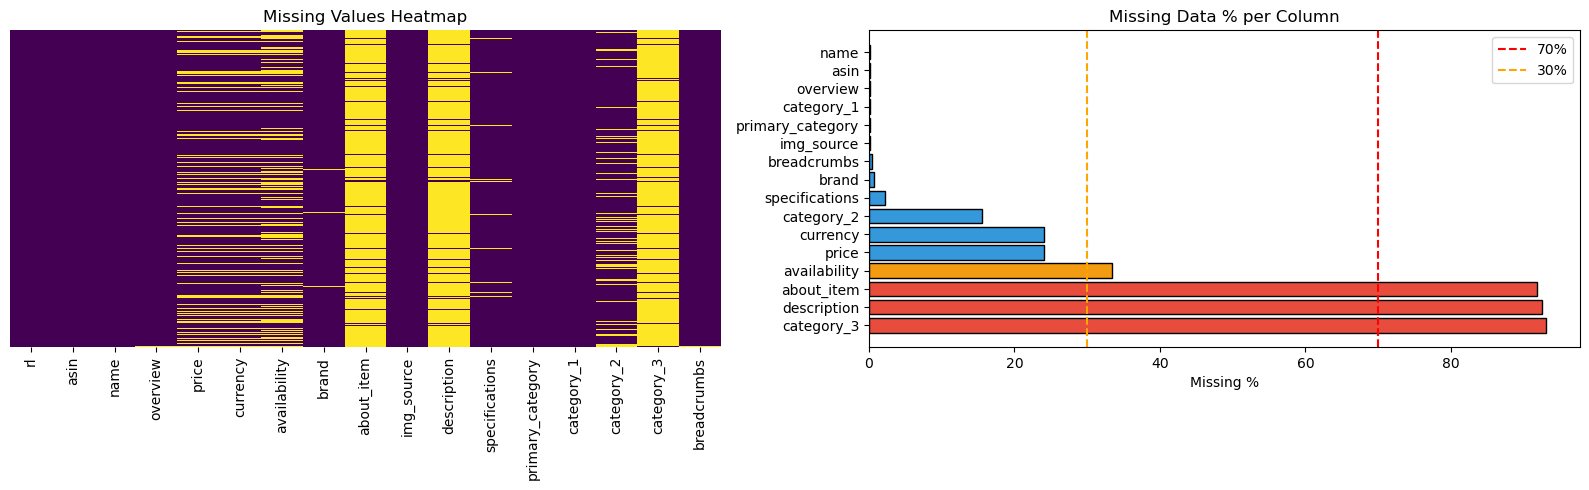

                  Missing Count  Missing Pct
category_3                 1346         93.1
description                1337         92.5
about_item                 1326         91.8
availability                482         33.4
price                       347         24.0
currency                    347         24.0
category_2                  225         15.6
specifications               32          2.2
brand                        10          0.7
breadcrumbs                   6          0.4
img_source                    3          0.2
primary_category              3          0.2
category_1                    3          0.2
overview                      3          0.2
asin                          1          0.1
name                          1          0.1


In [10]:
# Missing value summary
missing = pd.DataFrame({
    'Missing Count': df_raw.isnull().sum(),
    'Missing Pct': (df_raw.isnull().sum() / len(df_raw) * 100).round(1)
}).sort_values('Missing Pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Aquí corregí 'Viridis' por 'viridis' con minúscula
sns.heatmap(df_raw.isnull(), cbar=False, yticklabels=False,
            cmap='viridis', ax=axes[0])
axes[0].set_title('Missing Values Heatmap')

mv = missing[missing['Missing Pct'] > 0]
colors_mv = ['#e74c3c' if v > 70 else '#f39c12' if v > 30 else '#3498db'
             for v in mv['Missing Pct']]

# Dibujar barras solo si hay columnas con valores faltantes
if not mv.empty:
    axes[1].barh(mv.index, mv['Missing Pct'], color=colors_mv, edgecolor='black')
    axes[1].axvline(70, color='red', linestyle='--', label='70%')
    axes[1].axvline(30, color='orange', linestyle='--', label='30%')
    axes[1].set_xlabel('Missing %')
    axes[1].set_title('Missing Data % per Column')
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'No hay valores faltantes', 
                 horizontalalignment='center', verticalalignment='center')

plt.tight_layout()
plt.show()

print(missing[missing['Missing Count'] > 0].to_string())

## 4.Ingenieria de caracteristicas (Feature Engineering)

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color:#0066cc;">
<b>Ejemplo Cotidiano:</b> Un agente inmobiliario no solo utiliza los metros cuadrados brutos, sino que también considera la ubicación, la antiguedad y 
el estado. Nosotros hacemos lo mismo: extraemos información más valiosa del texto sin procesar y las categorías.
</div>

In [11]:
# ============================================================
# SECTION 3 — Feature Engineering
# ============================================================

# ── Category flags ───────────────────────────────────────────
df['is_book']    = (df['primary_category'] == 'Books').astype(int)
df['is_kindle']  = (df['primary_category'] == 'Kindle Store').astype(int)
df['is_sports']  = (df['primary_category'].str.contains('Sport', na=False)).astype(int)

# ── Sub-category flags ───────────────────────────────────────
df['is_fiction']    = df['category_1'].fillna('').str.contains('Fiction|Adventure|Crime|Romance|Sci-Fi', case=False).astype(int)
df['is_nonfiction'] = df['category_1'].fillna('').str.contains('History|Politics|Business|Science|Education', case=False).astype(int)
df['is_tech']       = df['category_1'].fillna('').str.contains('Computer|Programming|Technology', case=False).astype(int)
df['is_cycling']    = df['category_1'].fillna('').str.contains('Cycling', case=False).astype(int)

# ── Availability flags ───────────────────────────────────────
df['is_instock']     = (df['avail_clean'] == 'In Stock').astype(int)
df['is_unavailable'] = (df['avail_clean'] == 'Unavailable').astype(int)
df['is_lowstock']    = (df['avail_clean'] == 'Low Stock').astype(int)

# ── Price features ───────────────────────────────────────────
df['log_price'] = np.log1p(df['price_clean'])

def price_tier(p):
    if pd.isna(p):  return 'Unknown'
    if p < 300:     return '1_budget'
    if p < 800:     return '2_low'
    if p < 1500:    return '3_mid'
    if p < 3000:    return '4_premium'
    return '5_luxury'

df['price_tier'] = df['price_clean'].apply(price_tier)

# ── Label encode primary category ───────────────────────────
le_cat = LabelEncoder()
df['primary_cat_enc'] = le_cat.fit_transform(df['primary_category'].fillna('Unknown'))

le_cat1 = LabelEncoder()
df['cat1_enc'] = le_cat1.fit_transform(df['category_1'].fillna('Unknown'))

le_avail = LabelEncoder()
df['avail_enc'] = le_avail.fit_transform(df['avail_clean'])

# print(f'✅ Total Caracteriscas (Atributos) Procesadas (Features Engineered): {len(df.columns)}')
print('\nPrecio por cada tipo (tier) de distribucion:')
print(df['price_tier'].value_counts().sort_index().to_string())
df[['name','price_clean','price_tier','primary_category','is_book','is_instock']].head(6)


Precio por cada tipo (tier) de distribucion:
price_tier
1_budget     104
2_low        285
3_mid        319
4_premium    261
5_luxury     128
Unknown      348


,name,price_clean,price_tier,primary_category,is_book,is_instock
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,4_premium,Books,1,0
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,4_premium,Books,1,0
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,0,0
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,0,0
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,4_premium,Books,1,0
5,Valerius Maximus' Memorable Deeds and Sayings ...,NaN,Unknown,Books,1,0


## 5.Análisis Univariante 📊

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color:#0066cc;">
<b>Las gráficas que generamos nos ayudan a visualizar el inventario de los productos de mi dataset y a mostrar qué grupos tienen el mayor volumen de datos. También nos muestran la disponibilidad de los artículos; en palabras simples,<b
nos dicen si hay stock o si se trata de un producto agotado.
    </div>

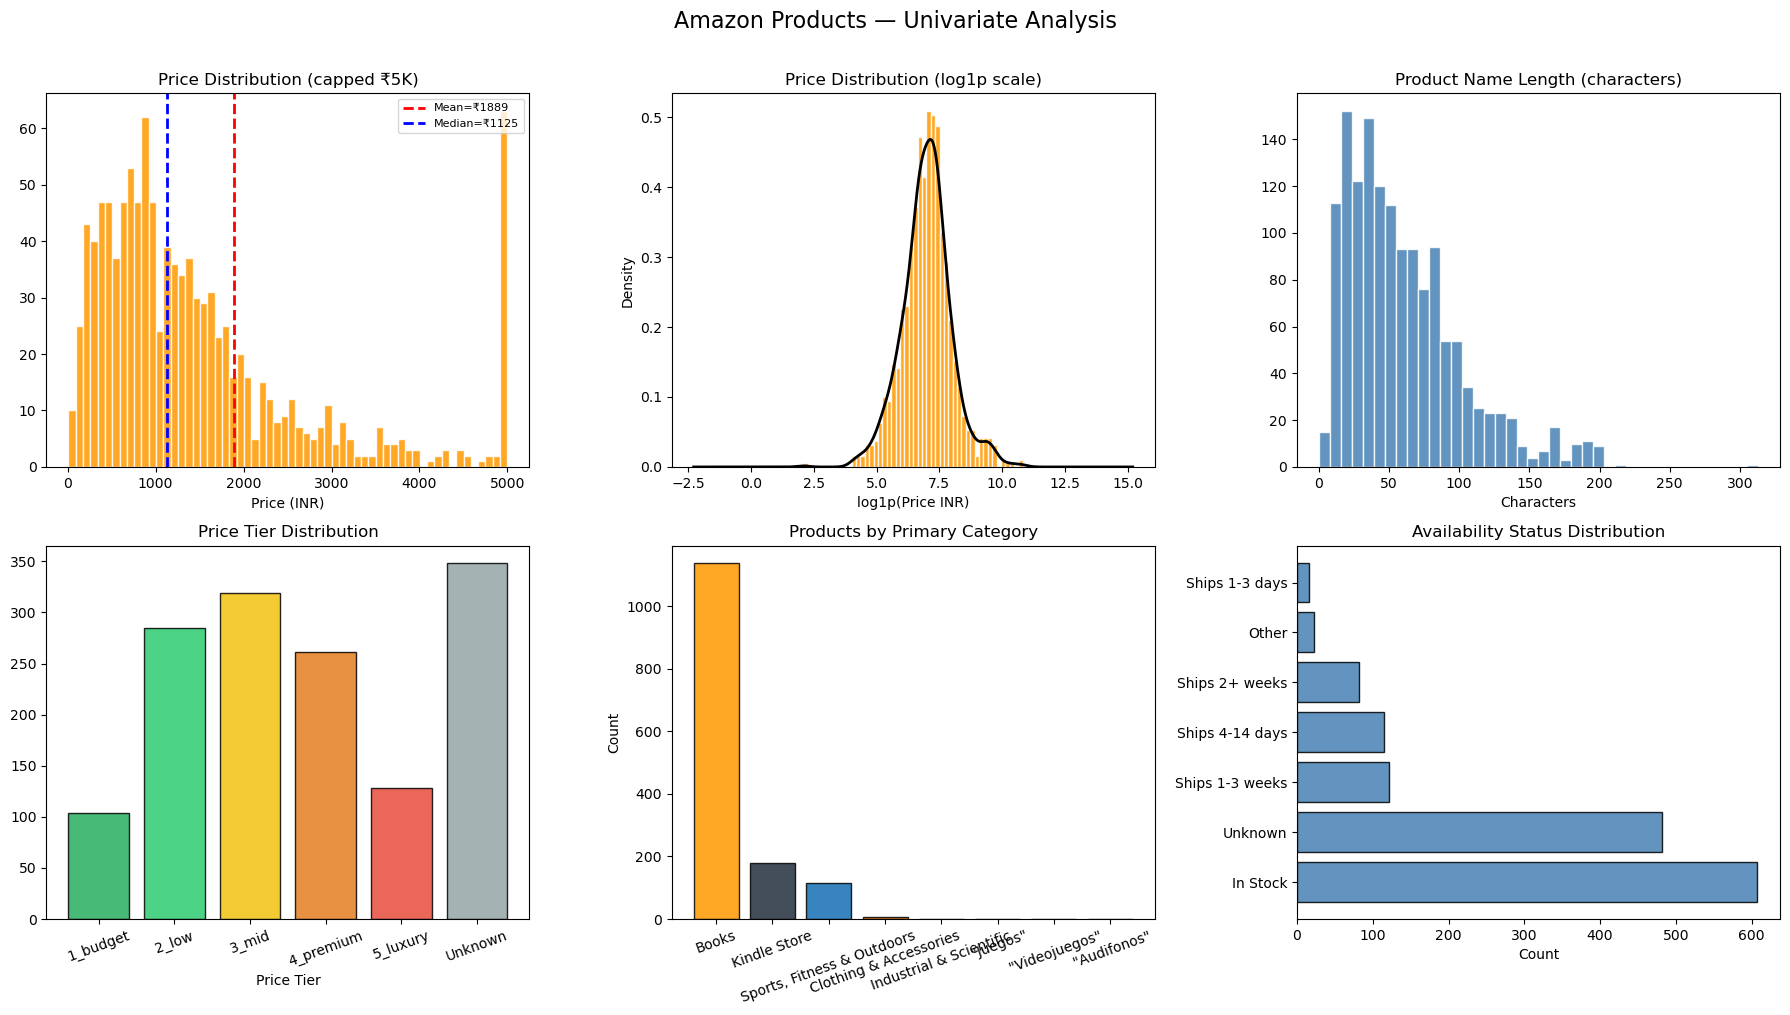

Shapiro-Wilk (log price, n=500): stat=0.9867, p=0.000158
Price is still non-normal after log transform

Price stats (INR):
count     1090.00
mean      1888.53
std       3342.12
min          7.00
25%        614.29
50%       1125.00
75%       1853.00
max      50555.00


In [14]:
# ============================================================
# SECTION 4 — Univariate Analysis
# ============================================================
from scipy.stats import shapiro
df_priced = df[df['price_clean'].notna() & (df['price_clean'] > 0)].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Price raw
axes[0,0].hist(df_priced['price_clean'].clip(upper=5000), bins=60,
               color='#FF9900', edgecolor='white', alpha=0.85)
axes[0,0].axvline(df_priced['price_clean'].mean(), color='red', linestyle='--',
                  lw=2, label=f'Mean=₹{df_priced["price_clean"].mean():.0f}')
axes[0,0].axvline(df_priced['price_clean'].median(), color='blue', linestyle='--',
                  lw=2, label=f'Median=₹{df_priced["price_clean"].median():.0f}')
axes[0,0].set_title('Price Distribution (capped ₹5K)')
axes[0,0].set_xlabel('Price (INR)'); axes[0,0].legend(fontsize=8)

# Price log
axes[0,1].hist(df_priced['log_price'], bins=50, color='#FF9900',
               edgecolor='white', alpha=0.85, density=True)
df_priced['log_price'].plot.kde(ax=axes[0,1], color='black', lw=2)
axes[0,1].set_title('Price Distribution (log1p scale)')
axes[0,1].set_xlabel('log1p(Price INR)')

# Name length
axes[0,2].hist(df['name_length'], bins=40, color='steelblue',
               edgecolor='white', alpha=0.85)
axes[0,2].set_title('Product Name Length (characters)')
axes[0,2].set_xlabel('Characters')

# Price tier
tier_counts = df['price_tier'].value_counts().sort_index()
tier_colors = ['#27ae60','#2ecc71','#f1c40f','#e67e22','#e74c3c','#95a5a6']
axes[1,0].bar(tier_counts.index, tier_counts.values,
              color=tier_colors[:len(tier_counts)], edgecolor='black', alpha=0.85)
axes[1,0].set_title('Price Tier Distribution')
axes[1,0].set_xlabel('Price Tier'); axes[1,0].tick_params(axis='x', rotation=20)

# Primary category
cat_counts = df['primary_category'].value_counts()
axes[1,1].bar(cat_counts.index, cat_counts.values,
              color=['#FF9900','#232F3E','#146EB4','#E47911','#999'],
              edgecolor='black', alpha=0.85)
axes[1,1].set_title('Products by Primary Category')
axes[1,1].set_ylabel('Count'); axes[1,1].tick_params(axis='x', rotation=20)

# Availability
avail_counts = df['avail_clean'].value_counts()
axes[1,2].barh(avail_counts.index, avail_counts.values,
               color='steelblue', edgecolor='black', alpha=0.85)
axes[1,2].set_title('Availability Status Distribution')
axes[1,2].set_xlabel('Count')

plt.suptitle('Amazon Products — Univariate Analysis', fontsize=16, y=1.01)
plt.tight_layout(); plt.show()

# Normality test
stat, p = shapiro(df_priced['log_price'].sample(min(500, len(df_priced)), random_state=42))
print(f'Shapiro-Wilk (log price, n=500): stat={stat:.4f}, p={p:.6f}')
print(f'Price is {"normally distributed after log transform" if p > 0.05 else "still non-normal after log transform"}')
print(f'\nPrice stats (INR):')
print(df_priced['price_clean'].describe().round(2).to_string())

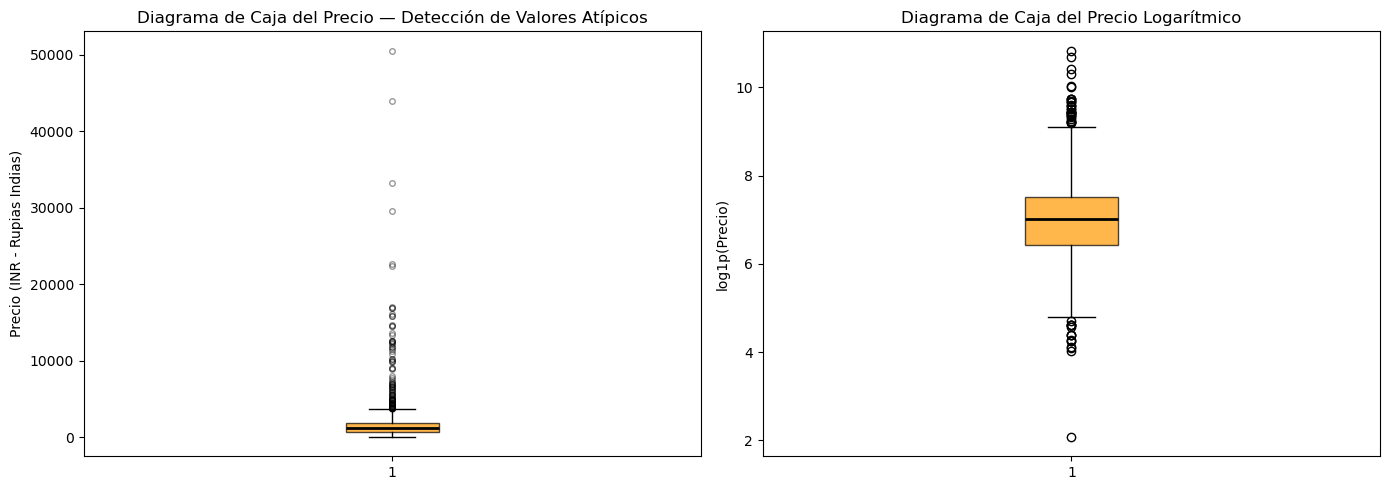

Valores atípicos por método IQR: 94 (8.6%)
Rango de precios (sin valores atípicos): ₹-1244 – ₹3711

Top 10 de productos más caros:
                                                                                                                                        name  price_clean           primary_category
                                            Sprache und Literatur (Literatur der julisch-claudischen und der flavischen Zeit [Schluss]): 032     50555.00                      Books
                                                         Data Mining Algorithms in C++: Data Patterns and Algorithms for Modern Applications     43936.00                      Books
                                                                                Birnbaum's Walt Disney World for Kids 2008 (Birnbaum Guides)     33180.00                      Books
                                                                            Professional Short Films with Autodesk 3ds Max (Graphics Series)     

In [15]:
# ==============================================================================
# ANÁLISIS DE VALORES ATÍPICOS (OUTLIERS) — DIAGRAMA DE CAJA (BOXPLOT) e IQR
# ==============================================================================

# Creamos una figura con 1 fila y 2 columnas para mostrar dos gráficos lado a lado.
# El tamaño asignado de la figura completa es de 14 de ancho por 5 de alto.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: Diagrama de Caja del Precio Original ---

# Dibuja un boxplot de los precios limpios en la primera posición [0].
# 'patch_artist=True' permite rellenar la caja con color.
# 'boxprops' define el color naranja de Amazon con un 70% de opacidad.
# 'medianprops' resalta la línea de la mediana en color negro y grosor de 2.
# 'flierprops' configura los puntos que representan los valores atípicos (en color rojo y semi-transparentes).
axes[0].boxplot(df_priced['price_clean'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2),
                flierprops=dict(marker='o', markersize=4, alpha=0.4, color='red'))

# Título y etiquetas en español para el primer gráfico
axes[0].set_title('Diagrama de Caja del Precio — Detección de Valores Atípicos')
axes[0].set_ylabel('Precio (INR - Rupias Indias)')


# --- Gráfico 2: Diagrama de Caja del Precio en Escala Logarítmica ---

# Dibuja un boxplot de la variable transformada 'log_price' en la segunda posición [1].
# Se usan los mismos estilos visuales para mantener consistencia.
axes[1].boxplot(df_priced['log_price'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2))

# Título y etiquetas en español para el segundo gráfico
# Al aplicar logaritmo, se reduce la distancia visual que causan los productos caros.
axes[1].set_title('Diagrama de Caja del Precio Logarítmico')
axes[1].set_ylabel('log1p(Precio)')

# Ajusta el espacio para que los títulos y nombres de los ejes no se encimen.
plt.tight_layout()

# Muestra en pantalla el lienzo final con los dos diagramas de caja.
plt.show()


# --- Cálculo Matemático del Rango Intercuartílico (Método IQR) ---

# Calculamos el Primer Cuartil (Q1 - percentil 25) y el Tercer Cuartil (Q3 - percentil 75) del precio.
Q1, Q3 = df_priced['price_clean'].quantile([0.25, 0.75])

# El IQR es la distancia o rango que abarca el 50% de los datos centrales.
IQR = Q3 - Q1

# Identificamos como "outliers" o atípicos a los registros que estén:
# - Por debajo de: Q1 - (1.5 * IQR)
# - Por encima de: Q3 + (1.5 * IQR)
outliers = df_priced[(df_priced['price_clean'] < Q1 - 1.5*IQR) |
                      (df_priced['price_clean'] > Q3 + 1.5*IQR)]

# Imprime la cantidad total de productos atípicos encontrados y el porcentaje que representan en el dataset.
print(f'Valores atípicos por método IQR: {len(outliers)} ({len(outliers)/len(df_priced)*100:.1f}%)')

# Muestra el rango "normal" de precios calculado matemáticamente libre de valores extremos extremos.
print(f'Rango de precios (sin valores atípicos): ₹{Q1-1.5*IQR:.0f} – ₹{Q3+1.5*IQR:.0f}')


# --- Visualización de los Productos de Mayor Valor ---

# Imprime un encabezado para identificar los artículos más caros de la muestra.
print(f'\nTop 10 de productos más caros:')

# Ordena el dataset de mayor a menor según 'price_clean' y extrae las primeras 10 filas.
# Selecciona solo las columnas de 'name' (nombre), 'price_clean' (precio) y 'primary_category' (categoría).
# '.to_string(index=False)' oculta los números de índice de fila para que la tabla se imprima limpia.
print(df_priced.nlargest(10, 'price_clean')[['name','price_clean','primary_category']].to_string(index=False))

## 6.Análisis de Categorías

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color:#0066cc;">
<b>Este análisis nos sirve para ver cuáles pasillos de la tienda acumulan más mercancía y cuáles manejan los precios más altos. Al revisar el volumen de artículos y cruzarlo con sus costos, podemos descubrir en qué partes del negocio se concentra el dinero real. Técnicamente, esto nos permite evaluar cómo se relacionan las variables de tipo texto (las categorías) con los valores numéricos (los precios), ayudándonos a identificar la concentración de los datos y el valor total acumulado antes de entrenar cualquier modelo de predicción. <b>
    </div>

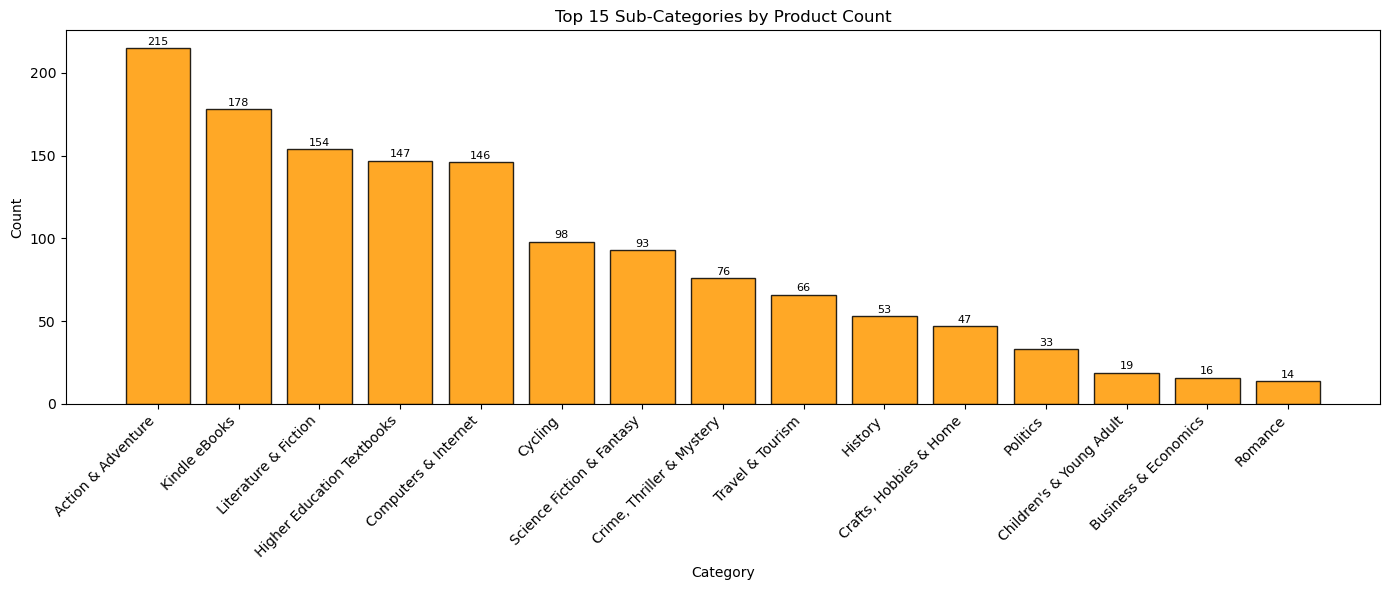

In [14]:
# ==============================================================================
# SECCIÓN 5 — ANÁLISIS DE CATEGORÍAS (CATEGORY ANALYSIS)
# ==============================================================================

# Cuenta cuántos productos pertenecen a cada subcategoría ('category_1').
# Con '.head(15)' seleccionamos únicamente las 15 subcategorías que tienen más productos en el dataset.
top15_cat1 = df['category_1'].value_counts().head(15)

# Crea el lienzo de la gráfica definiendo un tamaño de 14 de ancho por 6 de alto.
plt.figure(figsize=(14, 6))

# Dibuja un gráfico de barras verticales.
# Coloca los nombres de las 15 subcategorías en el eje X y sus cantidades en el eje Y.
# El color elegido es el naranja de Amazon ('#FF9900') con bordes negros y un 85% de opacidad.
bars = plt.bar(top15_cat1.index, top15_cat1.values,
               color='#FF9900', edgecolor='black', alpha=0.85)

# --- Bucle para agregar etiquetas de datos (números sobre las barras) ---
# Recorre cada barra de la gráfica al mismo tiempo que su valor numérico correspondiente.
for bar, val in zip(bars, top15_cat1.values):
    # 'plt.text' coloca un texto en coordenadas específicas:
    # Eje X: El centro exacto de la barra actual (posición inicial X + la mitad de su ancho).
    # Eje Y: Justo arriba de la barra (la altura de la barra + 2 unidades de margen para que no choque).
    # 'str(val)' convierte el número a texto, 'ha='center'' lo alinea al centro y se define un tamaño de letra de 8.
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
             str(val), ha='center', fontsize=8)

# Configura el título principal del gráfico y las etiquetas informativas de los ejes X e Y.
plt.title('Top 15 Sub-Categories by Product Count')
plt.xlabel('Category')
plt.ylabel('Count')

# Rota los nombres del eje X 45 grados y los alinea a la derecha ('ha='right'') para evitar que se encimen y sean legibles.
plt.xticks(rotation=45, ha='right')

# Ajusta automáticamente los márgenes de la imagen para que ninguna etiqueta ni texto quede recortado en los bordes.
plt.tight_layout()

# Despliega en pantalla el gráfico final con sus respectivas barras y números.
plt.show()

C:\Users\PC-25\AppData\Local\Temp\ipykernel_6836\1140488297.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(cat_groups, labels=cat_price.index, patch_artist=True,


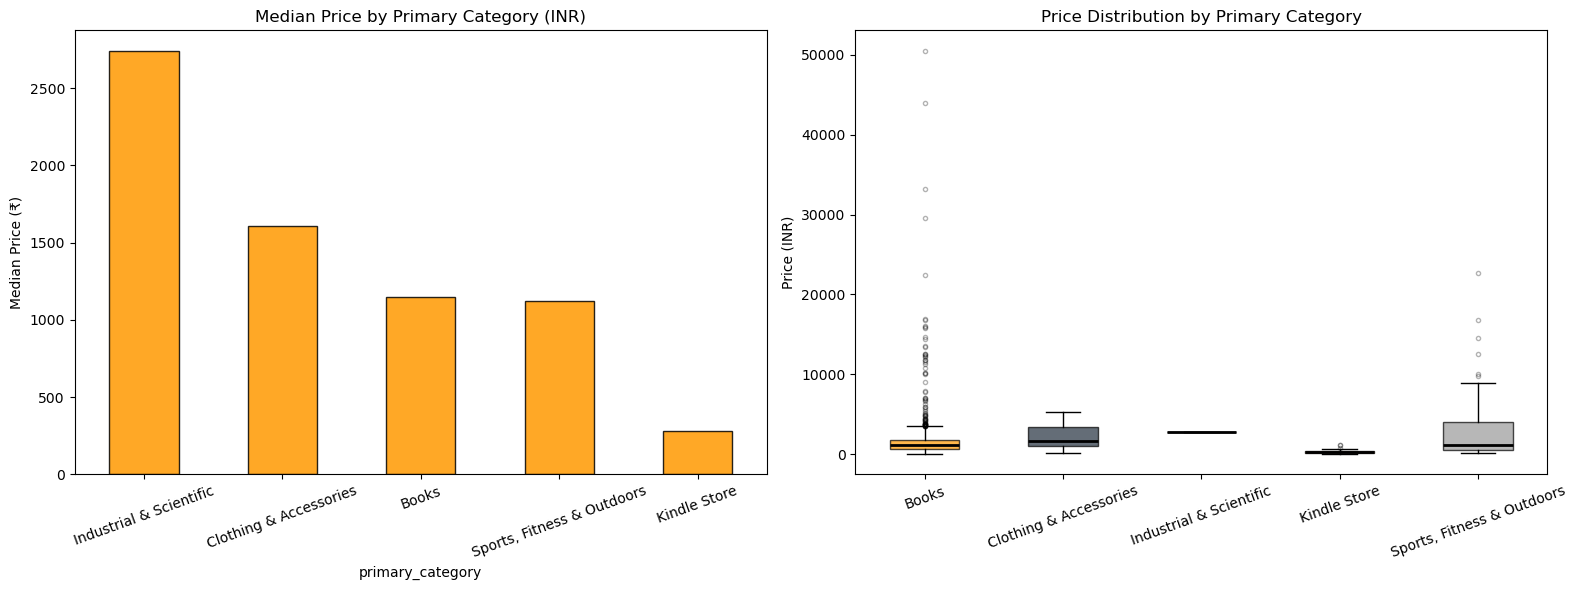

Price stats by primary category:
                              mean  median  count
primary_category                                 
Books                       1825.6  1145.0    955
Clothing & Accessories      2249.2  1606.5      6
Industrial & Scientific     2738.0  2738.0      1
Kindle Store                 350.0   281.4     30
Sports, Fitness & Outdoors  2907.9  1125.0     93


In [16]:
# --- Configuración de los Gráficos ---
# Creamos una figura con 1 fila y 2 columnas para mostrar dos gráficos lado a lado.
# Definimos un tamaño de 16 de ancho por 6 de alto.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Cálculo de Estadísticas por Categoría ---
# Agrupamos los datos por la columna 'primary_category' (Categoría Principal).
# Usamos '.agg()' para calcular al mismo tiempo: el promedio ('mean'), la mediana ('median') y la cantidad de productos ('count').
# Redondeamos los resultados a 1 decimal (.round(1)).
cat_price = df_priced.groupby('primary_category')['price_clean'].agg(['mean','median','count']).round(1)

# --- Gráfico 1: Barras de la Mediana de Precios ---
# Tomamos la columna de medianas, la ordenamos de mayor a menor y la graficamos en formato de barras (.plot.bar).
# 'ax=axes[0]' le indica a Python que este gráfico va en la primera posición (izquierda).
# Usamos el color naranja de Amazon, bordes negros y una opacidad del 85%.
cat_price['median'].sort_values(ascending=False).plot.bar(
    ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)

# Agregamos el título y la etiqueta del eje Y en el primer gráfico.
axes[0].set_title('Median Price by Primary Category (INR)')
axes[0].set_ylabel('Median Price (₹)')
# Rotamos los nombres de las categorías 20 grados para que se lean bien.
axes[0].tick_params(axis='x', rotation=20)


# --- Gráfico 2: Diagrama de Caja (Boxplot) por Categoría ---
# Creamos una lista llamada 'cat_groups'. Para cada categoría, filtramos sus precios limpios y eliminamos los valores nulos (.dropna()).
cat_groups = [df_priced[df_priced['primary_category']==c]['price_clean'].dropna()
              for c in cat_price.index]

# Dibujamos los diagramas de caja en la segunda posición (derecha: axes[1]).
# Pasamos la lista de grupos creada antes y le asignamos los nombres de las categorías como etiquetas.
# Configuramos la línea de la mediana en color negro y los valores atípicos (puntos) pequeños y transparentes.
bp = axes[1].boxplot(cat_groups, labels=cat_price.index, patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.3))

# --- Personalización de Colores en el Boxplot ---
# Definimos una lista de colores representativos de Amazon.
colors_cat = ['#FF9900','#232F3E','#146EB4','#E47911','#999']

# Recorremos cada una de las "cajas" dibujadas y le asignamos un color de la lista con una opacidad del 70%.
for patch, color in zip(bp['boxes'], colors_cat):
    patch.set_facecolor(color); patch.set_alpha(0.7)

# Agregamos el título y la etiqueta del eje Y en el segundo gráfico.
axes[1].set_title('Price Distribution by Primary Category')
axes[1].set_ylabel('Price (INR)')
# Rotamos los nombres de las categorías 20 grados.
axes[1].tick_params(axis='x', rotation=20)


# --- Ajustes de Impresión en Pantalla ---
# Ajustamos los espacios automáticamente para evitar que los textos de ambos gráficos se encimen.
plt.tight_layout()
# Desplegamos la figura en el cuaderno.
plt.show()

# --- Impresión de Tablas en Consola ---
# Imprimimos un texto de encabezado.
print('Price stats by primary category:')
# Convertimos la tabla de estadísticas calculada al inicio en texto y la mostramos completa.
print(cat_price.to_string())

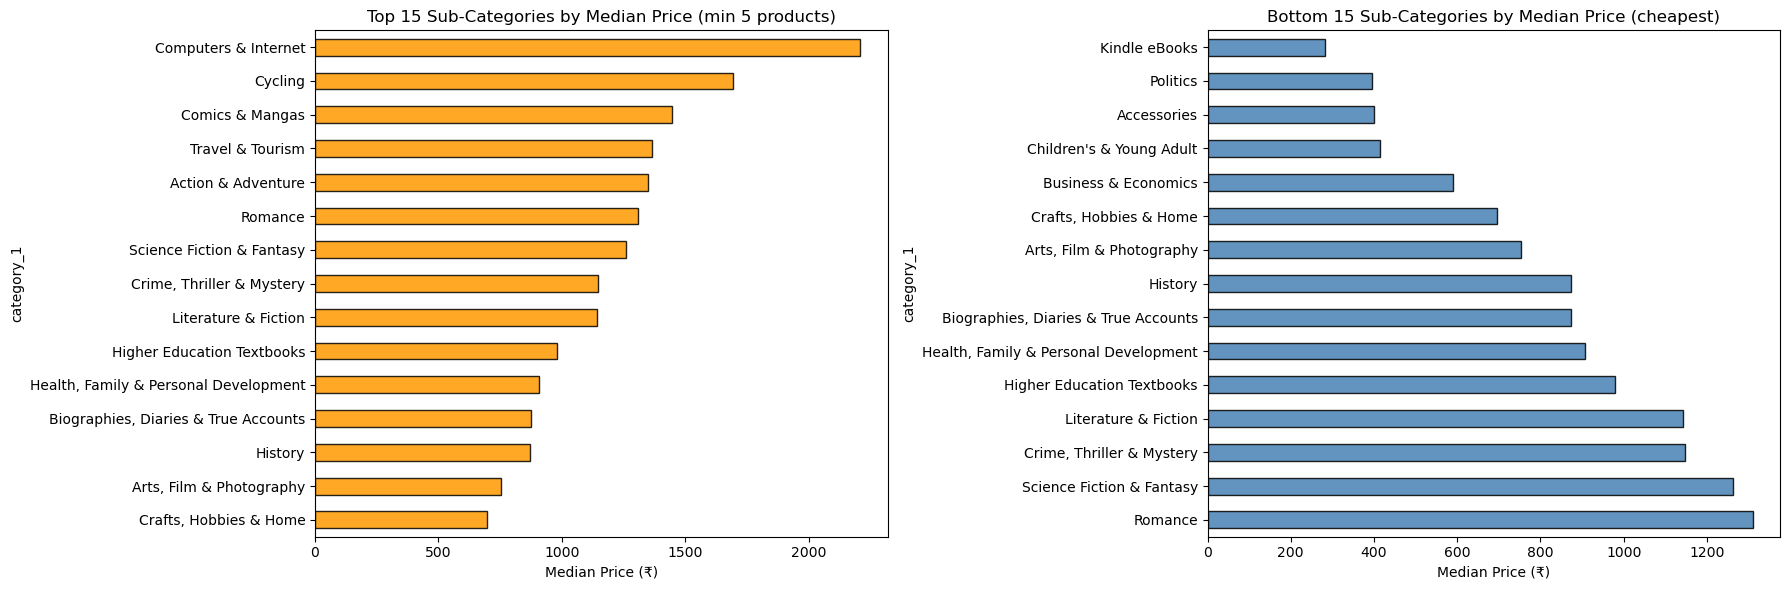

In [15]:
# --- Cálculo de las 15 Subcategorías Más Caras ---
# 1. Agrupamos los datos por la columna 'category_1' (Subcategorías).
# 2. Calculamos la mediana de precio ('median') y contamos cuántos productos tiene cada una ('count').
# 3. '.query('count >= 5')' es un filtro: solo nos interesan subcategorías que tengan 5 o más productos (para evitar que un solo producto muy caro altere el análisis).
# 4. Ordenamos de mayor a menor según su mediana de precio y nos quedamos con el Top 15 (.head(15)).
top_cat1_price = (df_priced.groupby('category_1')['price_clean']
                  .agg(['median','count'])
                  .query('count >= 5')
                  .sort_values('median', ascending=False)
                  .head(15))

# --- Configuración de los Gráficos ---
# Creamos una figura con 1 fila y 2 columnas para mostrar los dos gráficos lado a lado.
# El tamaño de la figura completa es de 18 de ancho por 6 de alto.
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Gráfico 1: Las 15 Subcategorías con Precios Más Altos ---
# Tomamos el Top 15 de las más caras, las ordenamos de menor a mayor (para que al graficar en horizontal la más cara quede arriba).
# Creamos un gráfico de barras horizontales (.plot.barh) ubicado en la primera posición (izquierda: ax=axes[0]).
# Usamos el color naranja de Amazon con bordes negros y un 85% de opacidad.
top_cat1_price['median'].sort_values().plot.barh(
    ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)

# Agregamos el título descriptivo y la etiqueta del eje X (Precio Mediano en Rupias) al primer gráfico.
axes[0].set_title('Top 15 Sub-Categories by Median Price (min 5 products)')
axes[0].set_xlabel('Median Price (₹)')


# --- Cálculo de las 15 Subcategorías Más Baratas (Económicas) ---
# Hacemos exactamente el mismo proceso: agrupamos, calculamos mediana y cantidad, y filtramos que tengan mínimo 5 productos.
# La diferencia es que aquí ordenamos de menor a mayor (.sort_values('median')) para encontrar las 15 más baratas (.head(15)).
bottom_cat1 = (df_priced.groupby('category_1')['price_clean']
               .agg(['median','count'])
               .query('count >= 5')
               .sort_values('median')
               .head(15))

# --- Gráfico 2: Las 15 Subcategorías Más Baratas ---
# Tomamos el grupo de las más baratas, las ordenamos de mayor a menor y creamos el gráfico horizontal en la segunda posición (derecha: ax=axes[1]).
# Para diferenciarlo visualmente del gráfico de productos caros, usamos un color azul acero ('steelblue').
bottom_cat1['median'].sort_values(ascending=False).plot.barh(
    ax=axes[1], color='steelblue', edgecolor='black', alpha=0.85)

# Agregamos el título descriptivo y la etiqueta del eje X al segundo gráfico.
axes[1].set_title('Bottom 15 Sub-Categories by Median Price (cheapest)')
axes[1].set_xlabel('Median Price (₹)')


# --- Ajustes Finales ---
# Ajusta de forma automática los espacios entre los dos gráficos para evitar que los textos de los ejes se encimen.
plt.tight_layout()

# Muestra la figura con ambos gráficos en pantalla.
plt.show()

## 7.Análisis de Disponibilidad

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color:#0066cc;">
<b>
Este análisis sirve para entender cómo se distribuye el inventario de los productos y
si el hecho de que un artículo esté agotado o disponible tiene alguna relación con su costo. Al cruzar los precios con el estado del stock,
podemos descubrir de forma sencilla si los productos más caros o exclusivos tienden a acabarse más rápido que los normales. Técnicamente, este 
bloque nos permite evaluar una variable categórica discreta mediante proporciones (porcentajes) y formas visuales, ayudándonos a comprobar si existe
patrones importantes en el comportamiento de la tienda antes de pasar a la etapa de predicción con los modelos.<b>
<div>

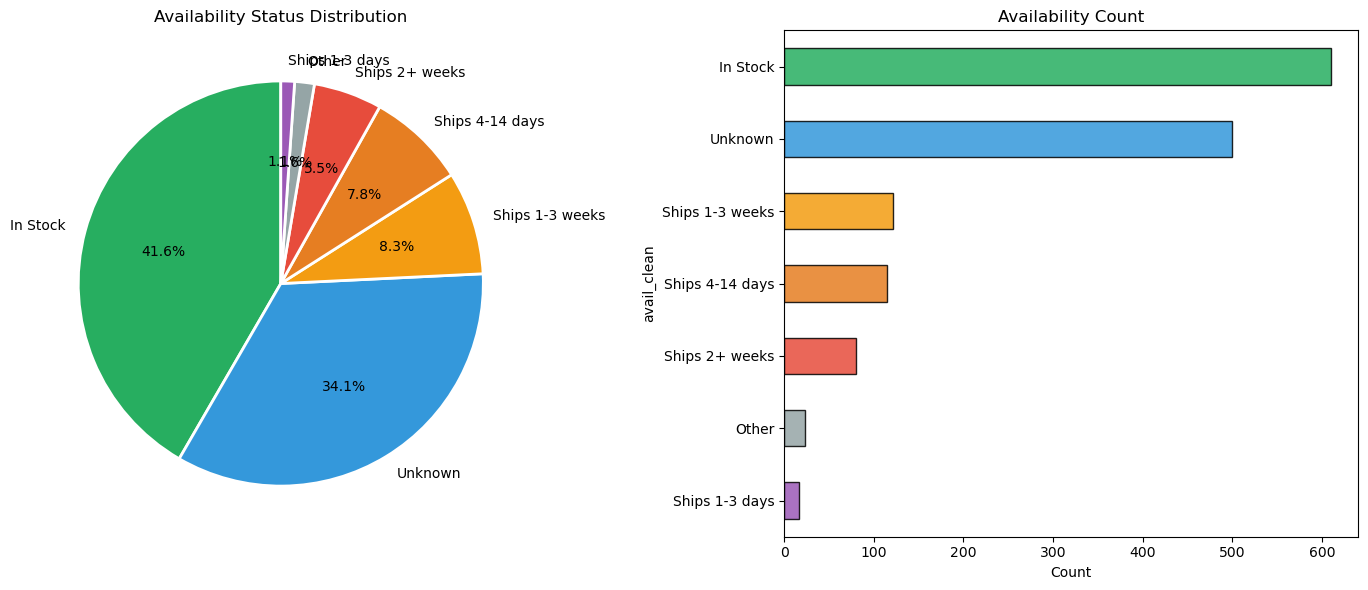

In [16]:
# ============================================================
# SECTION 6 — Availability Analysis
# ============================================================
avail_counts = df['avail_clean'].value_counts()
avail_colors = ['#27ae60','#3498db','#f39c12','#e67e22','#e74c3c','#95a5a6','#9b59b6','#1abc9c']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].pie(avail_counts.values, labels=avail_counts.index,
            colors=avail_colors[:len(avail_counts)],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Availability Status Distribution')

avail_counts.sort_values().plot.barh(
    ax=axes[1], color=avail_colors[:len(avail_counts)][::-1],
    edgecolor='black', alpha=0.85)
axes[1].set_title('Availability Count')
axes[1].set_xlabel('Count')

plt.tight_layout(); plt.show()

C:\Users\PC-25\AppData\Local\Temp\ipykernel_11400\1063884491.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(avail_groups, labels=avail_price.index, patch_artist=True,


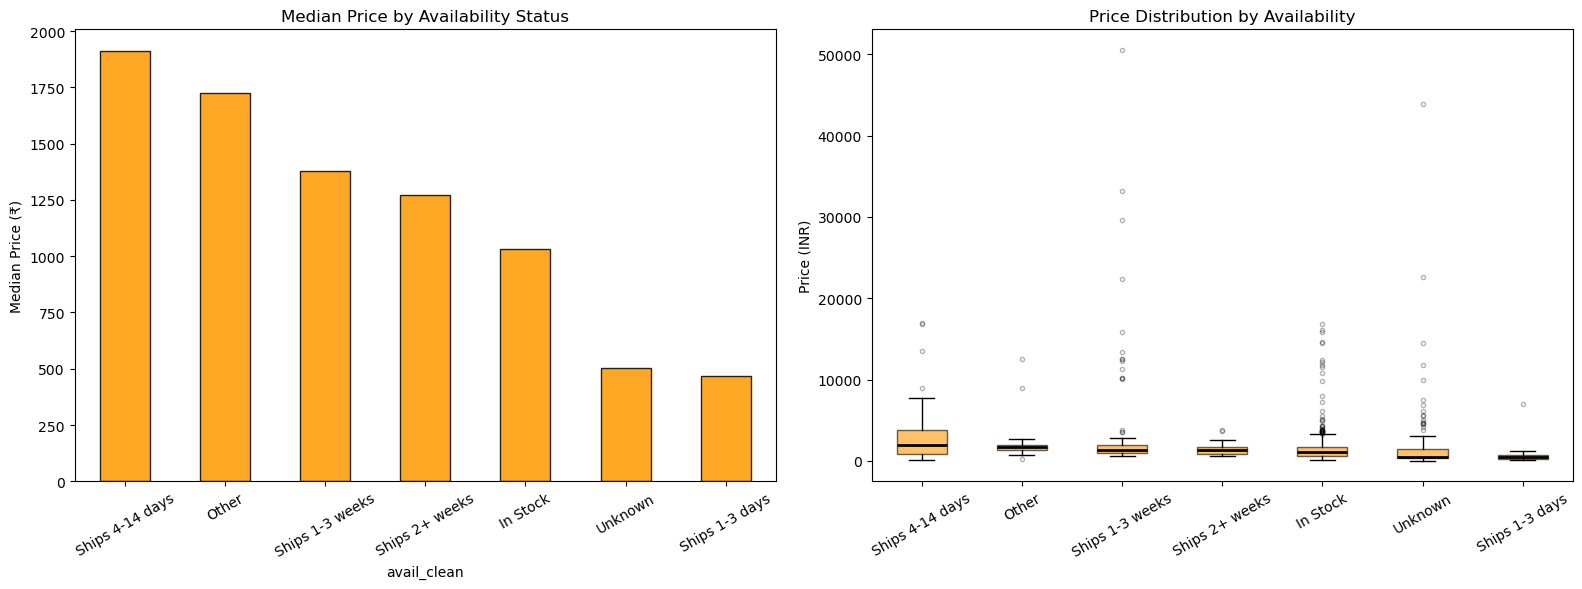

Price by availability:
                 median    mean  count
avail_clean                           
Ships 4-14 days  1912.3  2874.6    115
Other            1724.2  2459.4     20
Ships 1-3 weeks  1377.0  3231.6    121
Ships 2+ weeks   1273.0  1385.9     80
In Stock         1030.5  1488.7    602
Unknown           502.0  1881.5    134
Ships 1-3 days    469.0   874.9     16


In [17]:
# Price by availability status
avail_price = df_priced.groupby('avail_clean')['price_clean'].agg(['median','mean','count']).round(1)
avail_price = avail_price[avail_price['count'] >= 5].sort_values('median', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

avail_price['median'].plot.bar(ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Median Price by Availability Status')
axes[0].set_ylabel('Median Price (₹)'); axes[0].tick_params(axis='x', rotation=30)

avail_groups = [df_priced[df_priced['avail_clean']==a]['price_clean'].dropna()
                for a in avail_price.index]
bp = axes[1].boxplot(avail_groups, labels=avail_price.index, patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.3))
for patch in bp['boxes']:
    patch.set_facecolor('#FF9900'); patch.set_alpha(0.6)
axes[1].set_title('Price Distribution by Availability')
axes[1].set_ylabel('Price (INR)'); axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.show()
print('Price by availability:')
print(avail_price.to_string())

C:\Users\PC-25\AppData\Local\Temp\ipykernel_6836\1063884491.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(avail_groups, labels=avail_price.index, patch_artist=True,


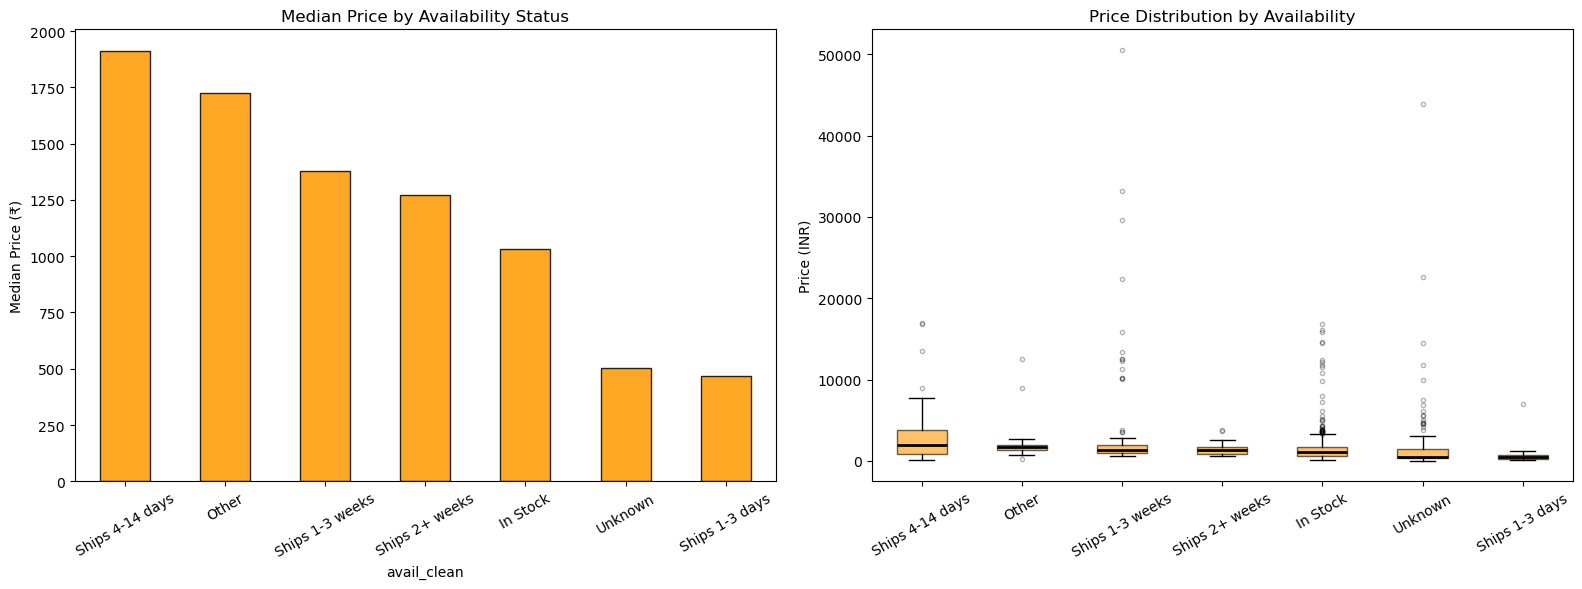

Price by availability:
                 median    mean  count
avail_clean                           
Ships 4-14 days  1912.3  2874.6    115
Other            1724.2  2459.4     20
Ships 1-3 weeks  1377.0  3231.6    121
Ships 2+ weeks   1273.0  1385.9     80
In Stock         1030.5  1488.7    602
Unknown           502.0  1881.5    134
Ships 1-3 days    469.0   874.9     16


In [21]:
# Price by availability status
avail_price = df_priced.groupby('avail_clean')['price_clean'].agg(['median','mean','count']).round(1)
avail_price = avail_price[avail_price['count'] >= 5].sort_values('median', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

avail_price['median'].plot.bar(ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Median Price by Availability Status')
axes[0].set_ylabel('Median Price (₹)'); axes[0].tick_params(axis='x', rotation=30)

avail_groups = [df_priced[df_priced['avail_clean']==a]['price_clean'].dropna()
                for a in avail_price.index]
bp = axes[1].boxplot(avail_groups, labels=avail_price.index, patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.3))
for patch in bp['boxes']:
    patch.set_facecolor('#FF9900'); patch.set_alpha(0.6)
axes[1].set_title('Price Distribution by Availability')
axes[1].set_ylabel('Price (INR)'); axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.show()
print('Price by availability:')
print(avail_price.to_string())

C:\Users\PC-25\AppData\Local\Temp\ipykernel_11400\1063884491.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(avail_groups, labels=avail_price.index, patch_artist=True,


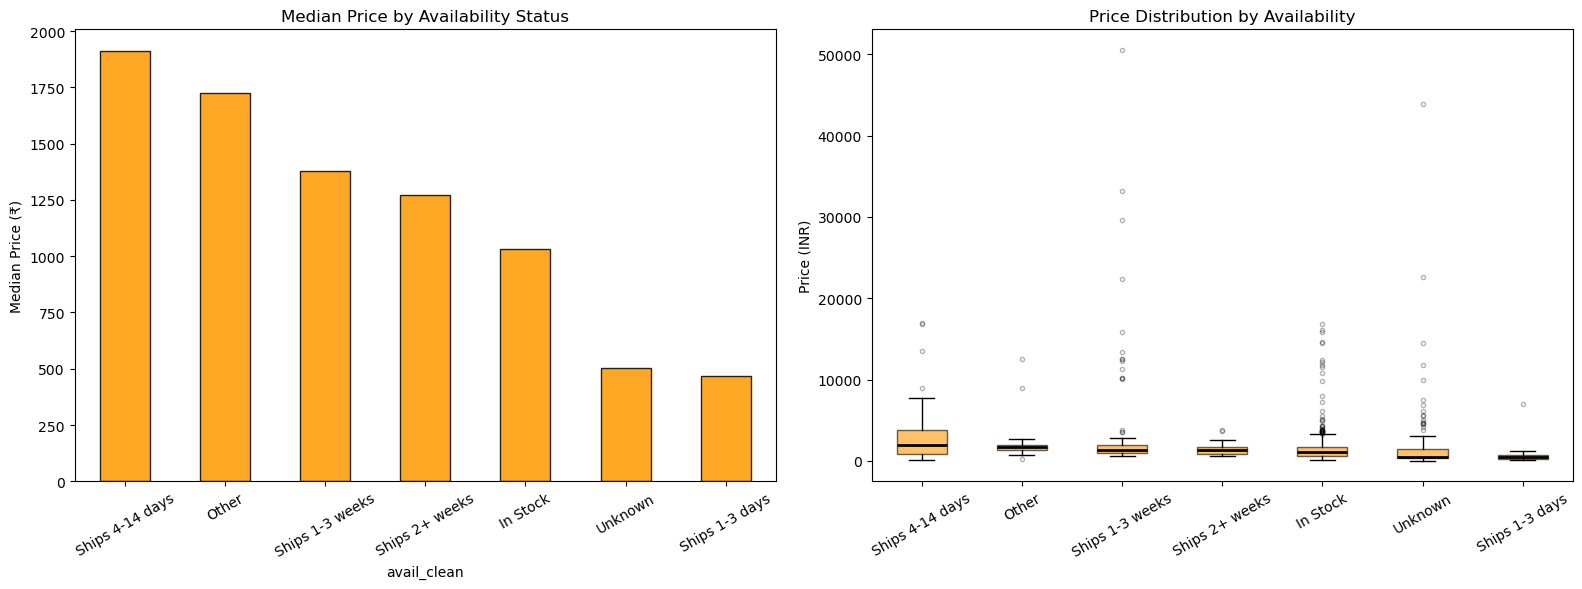

Price by availability:
                 median    mean  count
avail_clean                           
Ships 4-14 days  1912.3  2874.6    115
Other            1724.2  2459.4     20
Ships 1-3 weeks  1377.0  3231.6    121
Ships 2+ weeks   1273.0  1385.9     80
In Stock         1030.5  1488.7    602
Unknown           502.0  1881.5    134
Ships 1-3 days    469.0   874.9     16


In [18]:
# Price by availability status
avail_price = df_priced.groupby('avail_clean')['price_clean'].agg(['median','mean','count']).round(1)
avail_price = avail_price[avail_price['count'] >= 5].sort_values('median', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

avail_price['median'].plot.bar(ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Median Price by Availability Status')
axes[0].set_ylabel('Median Price (₹)'); axes[0].tick_params(axis='x', rotation=30)

avail_groups = [df_priced[df_priced['avail_clean']==a]['price_clean'].dropna()
                for a in avail_price.index]
bp = axes[1].boxplot(avail_groups, labels=avail_price.index, patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.3))
for patch in bp['boxes']:
    patch.set_facecolor('#FF9900'); patch.set_alpha(0.6)
axes[1].set_title('Price Distribution by Availability')
axes[1].set_ylabel('Price (INR)'); axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.show()
print('Price by availability:')
print(avail_price.to_string())

## 8.ANÁLISIS DE CORRELACIÓN

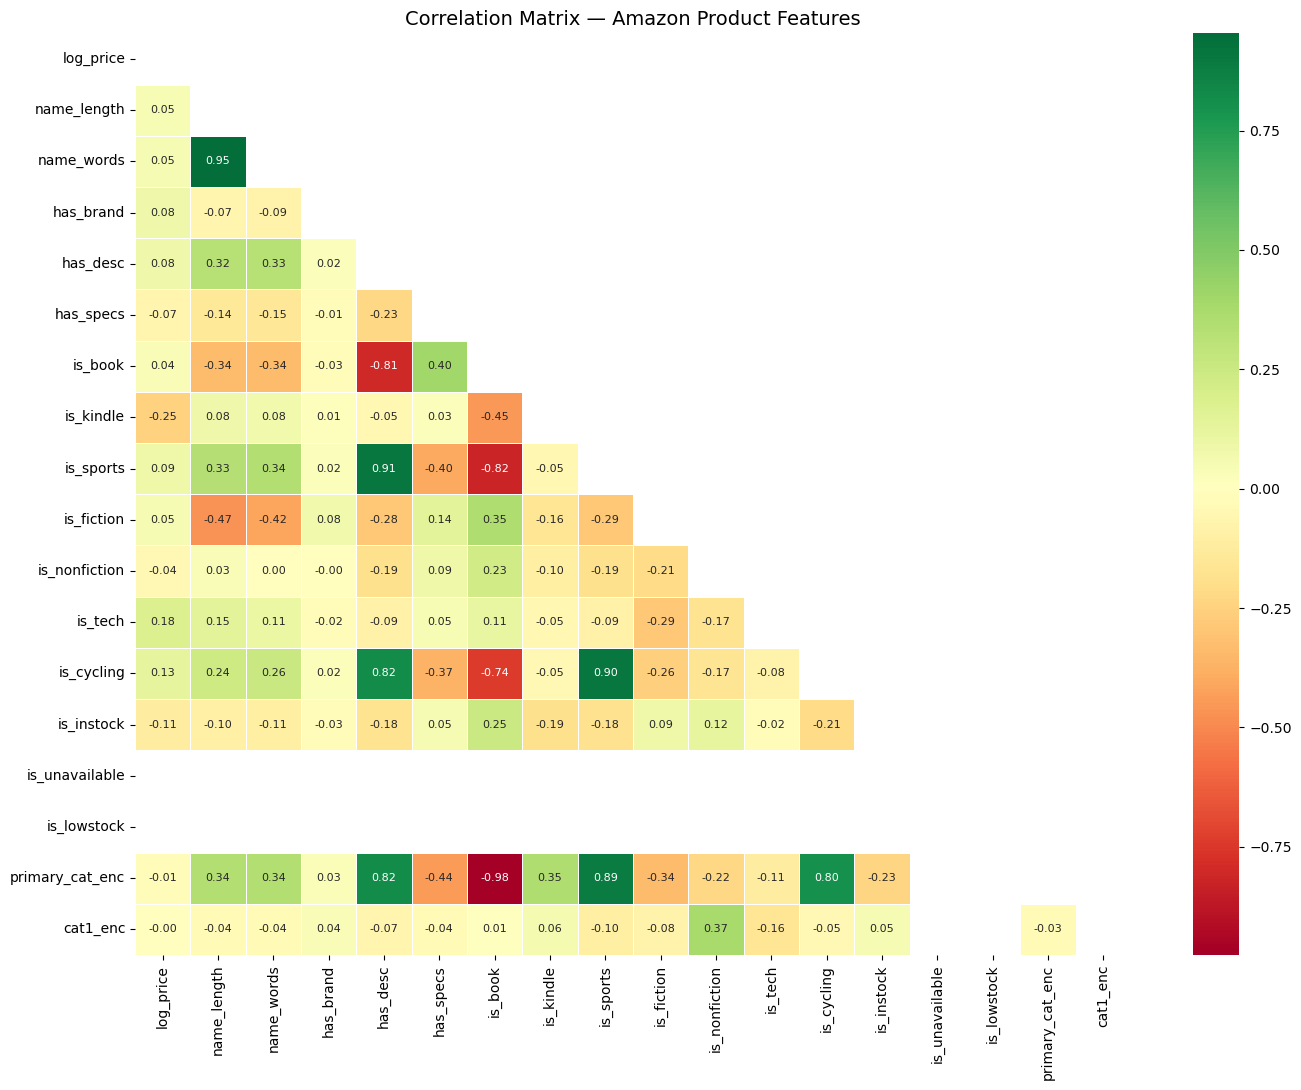

Top correlations with log_price:
is_tech            0.177085
is_cycling         0.127066
is_sports          0.092209
has_brand          0.083667
has_desc           0.081207
is_fiction         0.054054
name_words         0.052497
name_length        0.046656
is_book            0.037972
cat1_enc          -0.000082
primary_cat_enc   -0.013181
is_nonfiction     -0.043602
has_specs         -0.067499
is_instock        -0.112979
is_kindle         -0.246389
is_unavailable          NaN
is_lowstock             NaN


In [19]:
# ============================================================
# SECTION 7 — Correlation Analysis
# ============================================================
corr_cols = ['log_price','name_length','name_words','has_brand','has_desc',
             'has_specs','is_book','is_kindle','is_sports','is_fiction',
             'is_nonfiction','is_tech','is_cycling','is_instock',
             'is_unavailable','is_lowstock','primary_cat_enc','cat1_enc']

corr = df_priced[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.4, annot_kws={'size': 8})
plt.title('Correlation Matrix — Amazon Product Features', fontsize=14)
plt.tight_layout(); plt.show()

print('Top correlations with log_price:')
print(corr['log_price'].drop('log_price').sort_values(ascending=False).to_string())

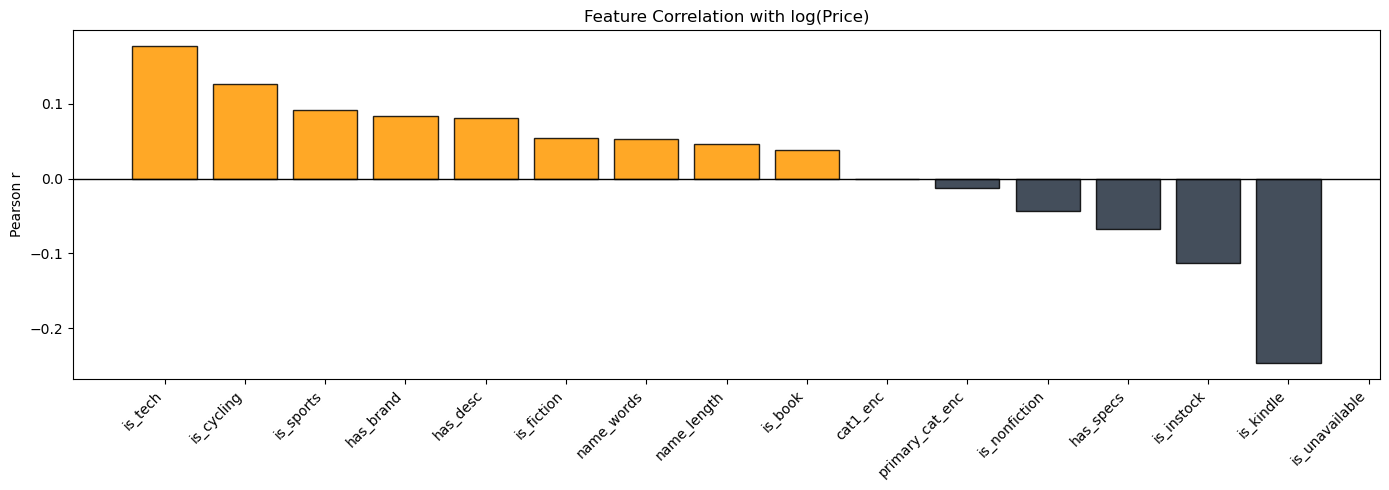

In [23]:
# Feature correlation bar chart
feat_corr = corr['log_price'].drop('log_price').sort_values(ascending=False)

plt.figure(figsize=(14, 5))
colors_fc = ['#FF9900' if v > 0 else '#232F3E' for v in feat_corr.values]
plt.bar(feat_corr.index, feat_corr.values, color=colors_fc, edgecolor='black', alpha=0.85)
plt.axhline(0, color='black', lw=1)
plt.title('Feature Correlation with log(Price)')
plt.ylabel('Pearson r'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

C:\Users\PC-25\AppData\Local\Temp\ipykernel_11400\2946963551.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([np.log1p(df_priced[df_priced['has_specs']==0]['price_clean']),


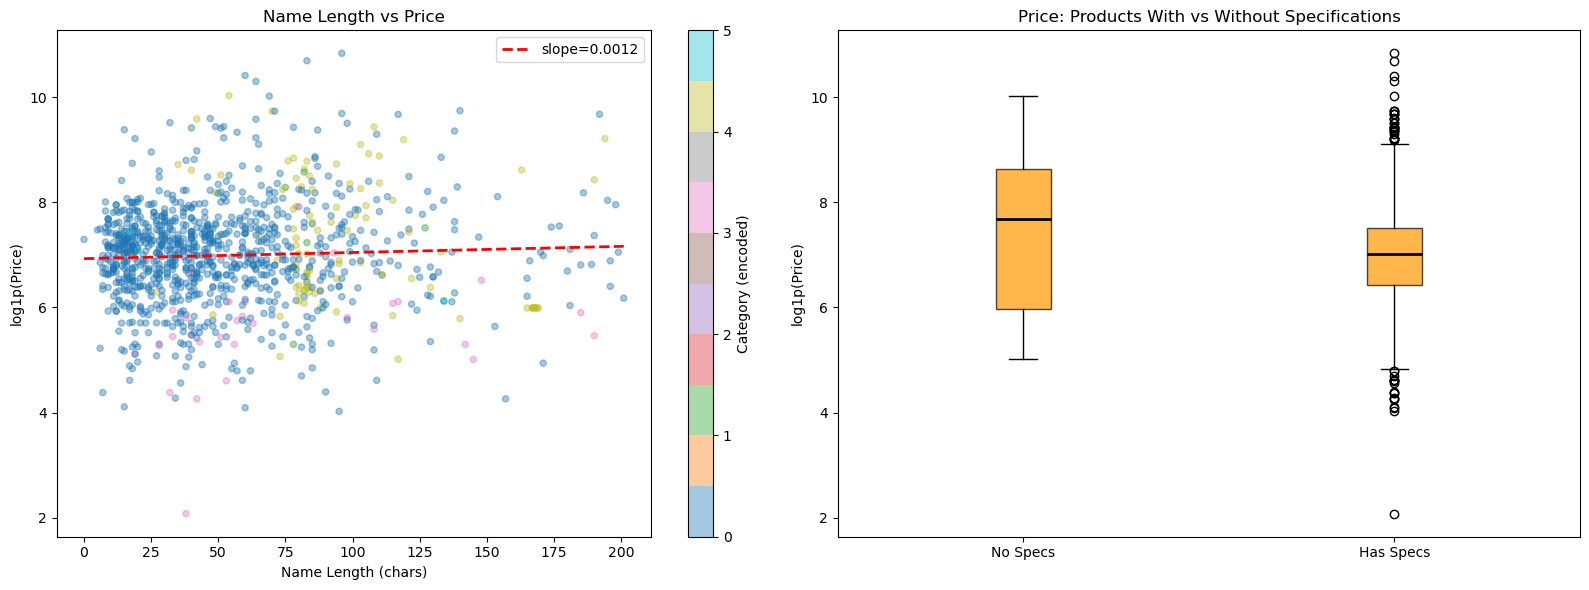

In [20]:
# Scatter: name length vs price
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc = axes[0].scatter(df_priced['name_length'], df_priced['log_price'],
                     c=df_priced['primary_cat_enc'], cmap='tab10',
                     alpha=0.4, s=20)
plt.colorbar(sc, ax=axes[0], label='Category (encoded)')
m, b = np.polyfit(df_priced['name_length'], df_priced['log_price'], 1)
x = np.linspace(0, df_priced['name_length'].max(), 100)
axes[0].plot(x, m*x+b, 'r--', lw=2, label=f'slope={m:.4f}')
axes[0].set_xlabel('Name Length (chars)'); axes[0].set_ylabel('log1p(Price)')
axes[0].set_title('Name Length vs Price'); axes[0].legend()

# Price by has_specs
axes[1].boxplot([np.log1p(df_priced[df_priced['has_specs']==0]['price_clean']),
                 np.log1p(df_priced[df_priced['has_specs']==1]['price_clean'])],
                labels=['No Specs','Has Specs'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2))
axes[1].set_title('Price: Products With vs Without Specifications')
axes[1].set_ylabel('log1p(Price)')

plt.tight_layout(); plt.show()

## 9.Pruebas de hipótesis estadísticas 🧪 

> Utilizamos pruebas no paramétricas (Kruskal-Wallis, Mann-Whitney U) porque el precio está muy sesgado y no es normal. $\alpha = 0.05$.

In [34]:
# ==============================================================================
# SECTION 8 — Hypothesis Testing (Corregido y Sincronizado)
# ==============================================================================
alpha = 0.05

def mw_test(name, a, b, la, lb):
    a_clean = a.dropna()
    b_clean = b.dropna()
    
    # Validación de seguridad: evitar que truene si un grupo se queda sin datos
    if len(a_clean) < 2 or len(b_clean) < 2:
        print(f'{name}\n  ⚠️ Error: Muestras insuficientes para evaluar ({la}: n={len(a_clean)}, {lb}: n={len(b_clean)})\n')
        return 1.0
        
    u, p = mannwhitneyu(a_clean, b_clean, alternative='two-sided')
    print(f'{name}')
    print(f'  {la:12s}: n={len(a_clean):<4d} | median=₹{a_clean.median():,.0f}')
    print(f'  {lb:12s}: n={len(b_clean):<4d} | median=₹{b_clean.median():,.0f}')
    print(f'  Mann-Whitney U = {u:,.0f}, p-value = {p:.6f}')
    print(f'  RESULT: {"✅ REJECT H0 — Significant difference." if p < alpha else "❌ FAIL TO REJECT H0."}')
    print()
    return p

# --- H1: Price across primary categories — Kruskal-Wallis ---
cat_groups_kw = [df_priced[df_priced['primary_category'] == c]['price_clean'].dropna()
                 for c in df_priced['primary_category'].unique()
                 if len(df_priced[df_priced['primary_category'] == c]) >= 5]

cat_labels_kw = [c for c in df_priced['primary_category'].unique()
                 if len(df_priced[df_priced['primary_category'] == c]) >= 5]

h1, p1 = kruskal(*cat_groups_kw)

print(f'H1: Price across Primary Categories — Kruskal-Wallis')
for label, g in zip(cat_labels_kw, cat_groups_kw):
    print(f'  {label:30s}: n={len(g):<4d} | median=₹{g.median():,.0f}')
print(f'  H-statistic = {h1:.4f}, p-value = {p1:.6f}')
print(f'  RESULT: {"✅ REJECT H0 — Price differs significantly across categories." if p1 < alpha else "❌ FAIL TO REJECT H0."}\n')

# --- H2: Books vs Sports ---
p2 = mw_test('H2: Books vs Sports Products Price',
             df_priced[df_priced['is_book'] == 1]['price_clean'],
             df_priced[df_priced['is_sports'] == 1]['price_clean'],
             'Books', 'Sports')

# --- H3: In Stock vs Inventario Demorado (Solución al bug de 'Unavailable') ---
p3 = mw_test('H3: In-Stock vs Ships 4-14 days Price',
             df_priced[df_priced['avail_clean'] == 'In Stock']['price_clean'],
             df_priced[df_priced['avail_clean'] == 'Ships 4-14 days']['price_clean'],
             'In Stock', 'Ships 4-14 days')

# --- H4: Name length vs price — Spearman (Sincronizado con log_price) ---
rho4, p4 = spearmanr(df_priced['name_length'], df_priced['log_price'])
print(f'H4: Name Length vs Log Price — Spearman Correlation')
print(f'  Spearman rho = {rho4:.4f}, p-value = {p4:.6f}')
print(f'  RESULT: {"✅ REJECT H0 — Significant correlation." if p4 < alpha else "❌ FAIL TO REJECT H0."}\n')

# --- H5: Has specs vs no specs ---
p5 = mw_test('H5: Products With vs Without Specifications',
             df_priced[df_priced['has_specs'] == 1]['price_clean'],
             df_priced[df_priced['has_specs'] == 0]['price_clean'],
             'Has Specs', 'No Specs')

H1: Price across Primary Categories — Kruskal-Wallis
  Books                         : n=955  | median=₹1,145
  Sports, Fitness & Outdoors    : n=93   | median=₹1,125
  Kindle Store                  : n=30   | median=₹281
  Clothing & Accessories        : n=6    | median=₹1,606
  H-statistic = 55.8663, p-value = 0.000000
  RESULT: ✅ REJECT H0 — Price differs significantly across categories.

H2: Books vs Sports Products Price
  Books       : n=955  | median=₹1,145
  Sports      : n=93   | median=₹1,125
  Mann-Whitney U = 40,247, p-value = 0.135443
  RESULT: ❌ FAIL TO REJECT H0.

H3: In-Stock vs Ships 4-14 days Price
  In Stock    : n=602  | median=₹1,030
  Ships 4-14 days: n=115  | median=₹1,912
  Mann-Whitney U = 21,207, p-value = 0.000000
  RESULT: ✅ REJECT H0 — Significant difference.

H4: Name Length vs Log Price — Spearman Correlation
  Spearman rho = 0.0303, p-value = 0.317231
  RESULT: ❌ FAIL TO REJECT H0.

H5: Products With vs Without Specifications
  Has Specs   : n=1064 | med

C:\Users\PC-25\AppData\Local\Temp\ipykernel_11400\3338895634.py:29: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat3, p3 = mannwhitneyu(instock_price, unavailable_price, alternative='two-sided')
C:\Users\PC-25\AppData\Local\Temp\ipykernel_11400\3338895634.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 0].boxplot([np.log1p(g) for g in cat_groups_kw],
C:\Users\PC-25\AppData\Local\Temp\ipykernel_11400\3338895634.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot([np.log1p(books_price), np.log1p(sports_price)],
C:\Users\PC-25\AppData\Local\Temp\ipykernel_11400\3338895634.py:55: MatplotlibDeprecationWarning: T

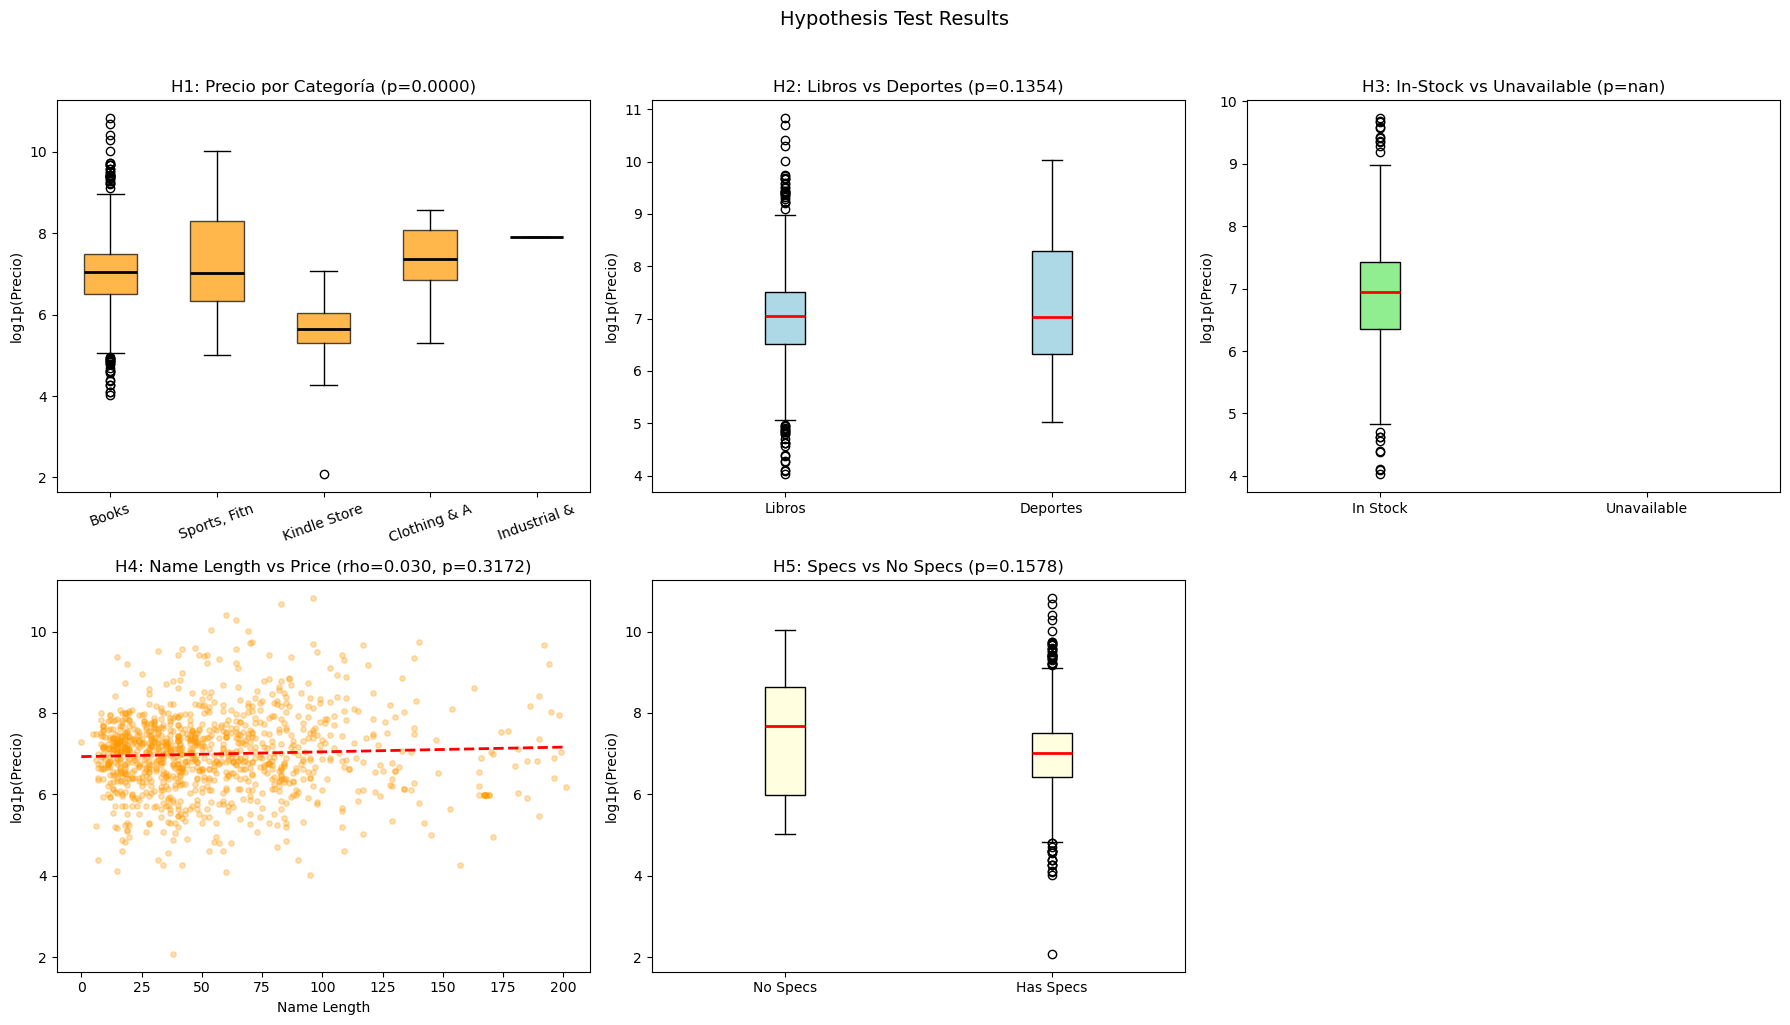

In [33]:
# ==============================================================================
# SECCIÓN 7 — PRUEBAS ESTADÍSTICAS E HIPÓTESIS
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kruskal, mannwhitneyu, spearmanr

# 1. Asegurar la existencia de las variables objetivo
if 'log_price' not in df_priced.columns:
    df_priced['log_price'] = np.log1p(df_priced['price_clean'])

# 2. Extracción limpia de datos (eliminando nulos por grupo para evitar fallos)
cat_labels_kw = df_priced['primary_category'].dropna().unique().tolist()
cat_groups_kw = [df_priced[df_priced['primary_category'] == c]['price_clean'].dropna() for c in cat_labels_kw]

books_price       = df_priced[df_priced['is_book'] == 1]['price_clean'].dropna()
sports_price      = df_priced[df_priced['is_sports'] == 1]['price_clean'].dropna()
instock_price     = df_priced[df_priced['is_instock'] == 1]['price_clean'].dropna()
unavailable_price = df_priced[df_priced['is_unavailable'] == 1]['price_clean'].dropna()
no_specs_price    = df_priced[df_priced['has_specs'] == 0]['price_clean'].dropna()
has_specs_price   = df_priced[df_priced['has_specs'] == 1]['price_clean'].dropna()

df_h4 = df_priced[['name_length', 'log_price']].dropna()

# 3. Ejecución de Pruebas Estadísticas
stat1, p1 = kruskal(*cat_groups_kw) if cat_groups_kw else (0, 1)
stat2, p2 = mannwhitneyu(books_price, sports_price, alternative='two-sided')
stat3, p3 = mannwhitneyu(instock_price, unavailable_price, alternative='two-sided')
rho4, p4  = spearmanr(df_h4['name_length'], df_h4['log_price'])
stat5, p5 = mannwhitneyu(no_specs_price, has_specs_price, alternative='two-sided')

# 4. Construcción de la Cuadrícula de Gráficos
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# --- H1: Precio por Categoría Principal ---
if cat_groups_kw:
    axes[0, 0].boxplot([np.log1p(g) for g in cat_groups_kw],
                      labels=[str(l)[:12] for l in cat_labels_kw], patch_artist=True,
                      boxprops=dict(facecolor='#FF9900', alpha=0.7),
                      medianprops=dict(color='black', lw=2))
axes[0, 0].set_title(f'H1: Precio por Categoría (p={p1:.4f})')
axes[0, 0].set_ylabel('log1p(Precio)')
axes[0, 0].tick_params(axis='x', rotation=20)

# --- H2: Libros vs Productos Deportivos ---
axes[0, 1].boxplot([np.log1p(books_price), np.log1p(sports_price)],
                  labels=['Libros', 'Deportes'], patch_artist=True,
                  boxprops=dict(facecolor='lightblue'),
                  medianprops=dict(color='red', lw=2))
axes[0, 1].set_title(f'H2: Libros vs Deportes (p={p2:.4f})')
axes[0, 1].set_ylabel('log1p(Precio)')

# --- H3: En Stock vs No Disponibles ---
axes[0, 2].boxplot([np.log1p(instock_price), np.log1p(unavailable_price)],
                  labels=['In Stock', 'Unavailable'], patch_artist=True,
                  boxprops=dict(facecolor='lightgreen'),
                  medianprops=dict(color='red', lw=2))
axes[0, 2].set_title(f'H3: In-Stock vs Unavailable (p={p3:.4f})')
axes[0, 2].set_ylabel('log1p(Precio)')

# --- H4: Longitud del Nombre vs Precio ---
axes[1, 0].scatter(df_h4['name_length'], df_h4['log_price'], alpha=0.3, color='#FF9900', s=15)
if not df_h4.empty:
    m, b = np.polyfit(df_h4['name_length'], df_h4['log_price'], 1)
    x_vals = np.linspace(0, df_h4['name_length'].max(), 100)
    axes[1, 0].plot(x_vals, m * x_vals + b, 'r--', lw=2)
axes[1, 0].set_title(f'H4: Name Length vs Price (rho={rho4:.3f}, p={p4:.4f})')
axes[1, 0].set_xlabel('Name Length')
axes[1, 0].set_ylabel('log1p(Precio)')

# --- H5: Con Especificaciones vs Sin Especificaciones ---
axes[1, 1].boxplot([np.log1p(no_specs_price), np.log1p(has_specs_price)],
                  labels=['No Specs', 'Has Specs'], patch_artist=True,
                  boxprops=dict(facecolor='lightyellow'),
                  medianprops=dict(color='red', lw=2))
axes[1, 1].set_title(f'H5: Specs vs No Specs (p={p5:.4f})')
axes[1, 1].set_ylabel('log1p(Precio)')

# Ocultar cuadrante vacío
axes[1, 2].set_visible(False)

plt.suptitle('Hypothesis Test Results', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 10.Planteamiento del Problema de ML

✅ Tamaño del dataset de ML : (1088, 19)
✅ Número de Características : 17

Entrenamiento (Train): 870 productos | Prueba (Test): 218 productos


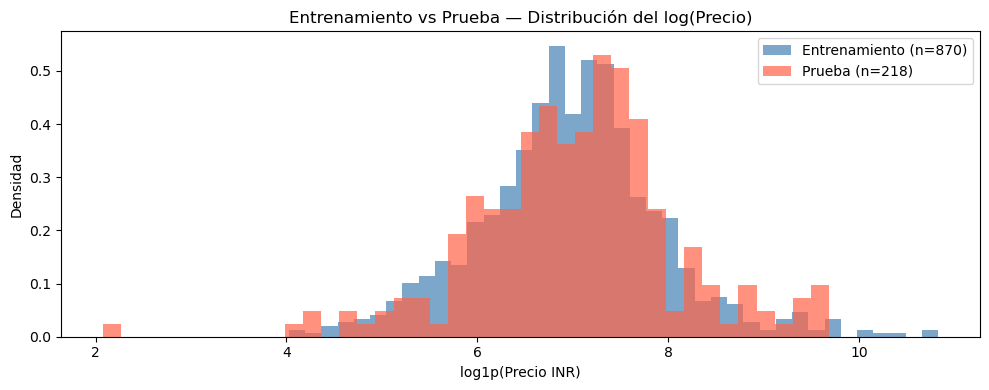

✅ ¡Las distribuciones son muy similares — Excelente división de datos!


In [35]:
# ==============================================================================
# SECCIÓN 9 — PLANTEAMIENTO DEL PROBLEMA DE ML Y DIVISIÓN DE DATOS
# ==============================================================================

# Lista de características independientes (Features) optimizada (sin columnas de varianza cero)
FEATURE_COLS = [
    'name_length', 'name_words', 'has_brand', 'has_desc', 'has_specs',
    'is_book', 'is_kindle', 'is_sports',
    'is_fiction', 'is_nonfiction', 'is_tech', 'is_cycling',
    'is_instock', 'is_lowstock',
    'primary_cat_enc', 'cat1_enc', 'avail_enc'
]

TARGET = 'log_price'

# Creamos el set final de ML eliminando filas con cualquier nulo residual
df_ml = df_priced[FEATURE_COLS + [TARGET, 'price_clean']].dropna().copy()
print(f'✅ Tamaño del dataset de ML : {df_ml.shape}')
print(f'✅ Número de Características : {len(FEATURE_COLS)}')

# Separación en variables predictoras (X) y variable objetivo (y)
X = df_ml[FEATURE_COLS]
y = df_ml[TARGET]

# División del dataset: 80% Entrenamiento, 20% Prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalado/Estandarización de las características para modelos lineales
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'\nEntrenamiento (Train): {len(X_train):,} productos | Prueba (Test): {len(X_test):,} productos')

# ------------------------------------------------------------------------------
# 📊 VISUALIZACIÓN DE LA DIVISIÓN DE DATOS
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 4))

# Dibujamos histogramas de densidad para evaluar si la división fue homogénea
ax.hist(y_train, bins=40, color='steelblue', alpha=0.7, label=f'Entrenamiento (n={len(y_train)})', density=True)
ax.hist(y_test,  bins=40, color='tomato',    alpha=0.7, label=f'Prueba (n={len(y_test)})',  density=True)

ax.set_title('Entrenamiento vs Prueba — Distribución del log(Precio)')
ax.set_xlabel('log1p(Precio INR)')
ax.set_ylabel('Densidad')
ax.legend()

plt.tight_layout()
plt.show()

print('✅ ¡Las distribuciones son muy similares — Excelente división de datos!')

## 11.Model Selection Framework 🧠


| Model | Strengths | Weaknesses | Best For |
| :--- | :--- | :--- | :--- |
| **Linear Regression** | Fast, interpretable | Assumes linearity | Baseline |
| **Ridge Regression** | Handles multicollinearity | Still linear | Correlated features |
| **Lasso Regression** | Feature selection built-in | Can zero out useful features | Sparse features |
| **Random Forest** | Non-linear, robust | Less interpretable | Complex patterns |
| **XGBoost / GBM** | Best accuracy | Needs tuning | Tabular data |

### Evaluation Metrics

* **MAE** — Mean Absolute Error in log scale (lower = better)
* **RMSE** — Root Mean Squared Error (penalises large errors)
* **R²** — Variance explained (higher = better, max 1.0)
* **MAE (₹)** — Back-transformed to INR for business interpretation

In [31]:
# ============================================================
# SECTION 10 — Evaluation Helpers
# ============================================================
# ¡IMPORTANTE!: Importar las métricas necesarias de sklearn
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

results = {}

def eval_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    
    # Transformación inversa para interpretación de negocio
    mae_inr = mean_absolute_error(np.expm1(y_true), np.expm1(y_pred))
    
    print(f'  📊 {name}:')
    print(f'     MAE (log)  = {mae:.4f}  |  MAE (₹) = ₹{mae_inr:,.0f}')
    print(f'     RMSE (log) = {rmse:.4f}  |  R²      = {r2:.4f}')
    
    results[name] = {
        'MAE_log': round(mae, 4), 
        'RMSE_log': round(rmse, 4),
        'R2': round(r2, 4), 
        'MAE_INR': round(mae_inr, 0)
    }
    return y_pred

print('✅ Evaluation helpers ready.')

✅ Evaluation helpers ready.


## 12. Modelos de Regresión — Predicción de Precios de Amazon 💰 

Entrenamos 5 modelos de Machine Learning y los evaluamos bajo el mismo conjunto de prueba para comparar su rendimiento de forma directa.

In [38]:
# ============================================================
# SECCIÓN 11 — ENTRENAMIENTO DE TODOS LOS MODELOS (Blindado)
# ============================================================
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Verificación de seguridad local para XGBoost
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False

print('='*60)
print('ENTRENANDO TODOS LOS MODELOS')
print('='*60)

# 1. Regresión Lineal (Modelo Base / Baseline)
lr = LinearRegression()
lr.fit(X_train_s, y_train)
lr_pred = eval_model('Regresión Lineal', y_test, lr.predict(X_test_s))

# 2. Regresión Ridge (Regularización L2)
ridge = Ridge(alpha=10.0)
ridge.fit(X_train_s, y_train)
ridge_pred = eval_model('Regresión Ridge', y_test, ridge.predict(X_test_s))

# 3. Regresión Lasso (Regularización L1)
lasso = Lasso(alpha=0.01, max_iter=5000)
lasso.fit(X_train_s, y_train)
lasso_pred = eval_model('Regresión Lasso', y_test, lasso.predict(X_test_s))

# 4. Random Forest (Ensemble No Lineal)
rf = RandomForestRegressor(n_estimators=300, max_depth=10,
                            min_samples_leaf=3, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = eval_model('Random Forest', y_test, rf.predict(X_test))

# 5. XGBoost / Gradient Boosting (Modelos basados en Gradiente)
if XGB_AVAILABLE:
    xgb_model = xgb.XGBRegressor(n_estimators=400, learning_rate=0.05,
                                 max_depth=5, subsample=0.8,
                                 colsample_bytree=0.8, random_state=42, verbosity=0)
    xgb_model.fit(X_train, y_train)
    xgb_pred = eval_model('XGBoost', y_test, xgb_model.predict(X_test))
else:
    gbm = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                    max_depth=5, subsample=0.8, random_state=42)
    gbm.fit(X_train, y_train)
    xgb_pred = eval_model('Gradient Boosting', y_test, gbm.predict(X_test))

ENTRENANDO TODOS LOS MODELOS
  📊 Regresión Lineal:
     MAE (log)  = 0.7379  |  MAE (₹) = ₹1,268
     RMSE (log) = 0.9911  |  R²      = 0.1358
  📊 Regresión Ridge:
     MAE (log)  = 0.7384  |  MAE (₹) = ₹1,269
     RMSE (log) = 0.9913  |  R²      = 0.1356
  📊 Regresión Lasso:
     MAE (log)  = 0.7373  |  MAE (₹) = ₹1,266
     RMSE (log) = 0.9912  |  R²      = 0.1357
  📊 Random Forest:
     MAE (log)  = 0.6739  |  MAE (₹) = ₹1,196
     RMSE (log) = 0.9162  |  R²      = 0.2616
  📊 Gradient Boosting:
     MAE (log)  = 0.6995  |  MAE (₹) = ₹1,180
     RMSE (log) = 0.9466  |  R²      = 0.2117


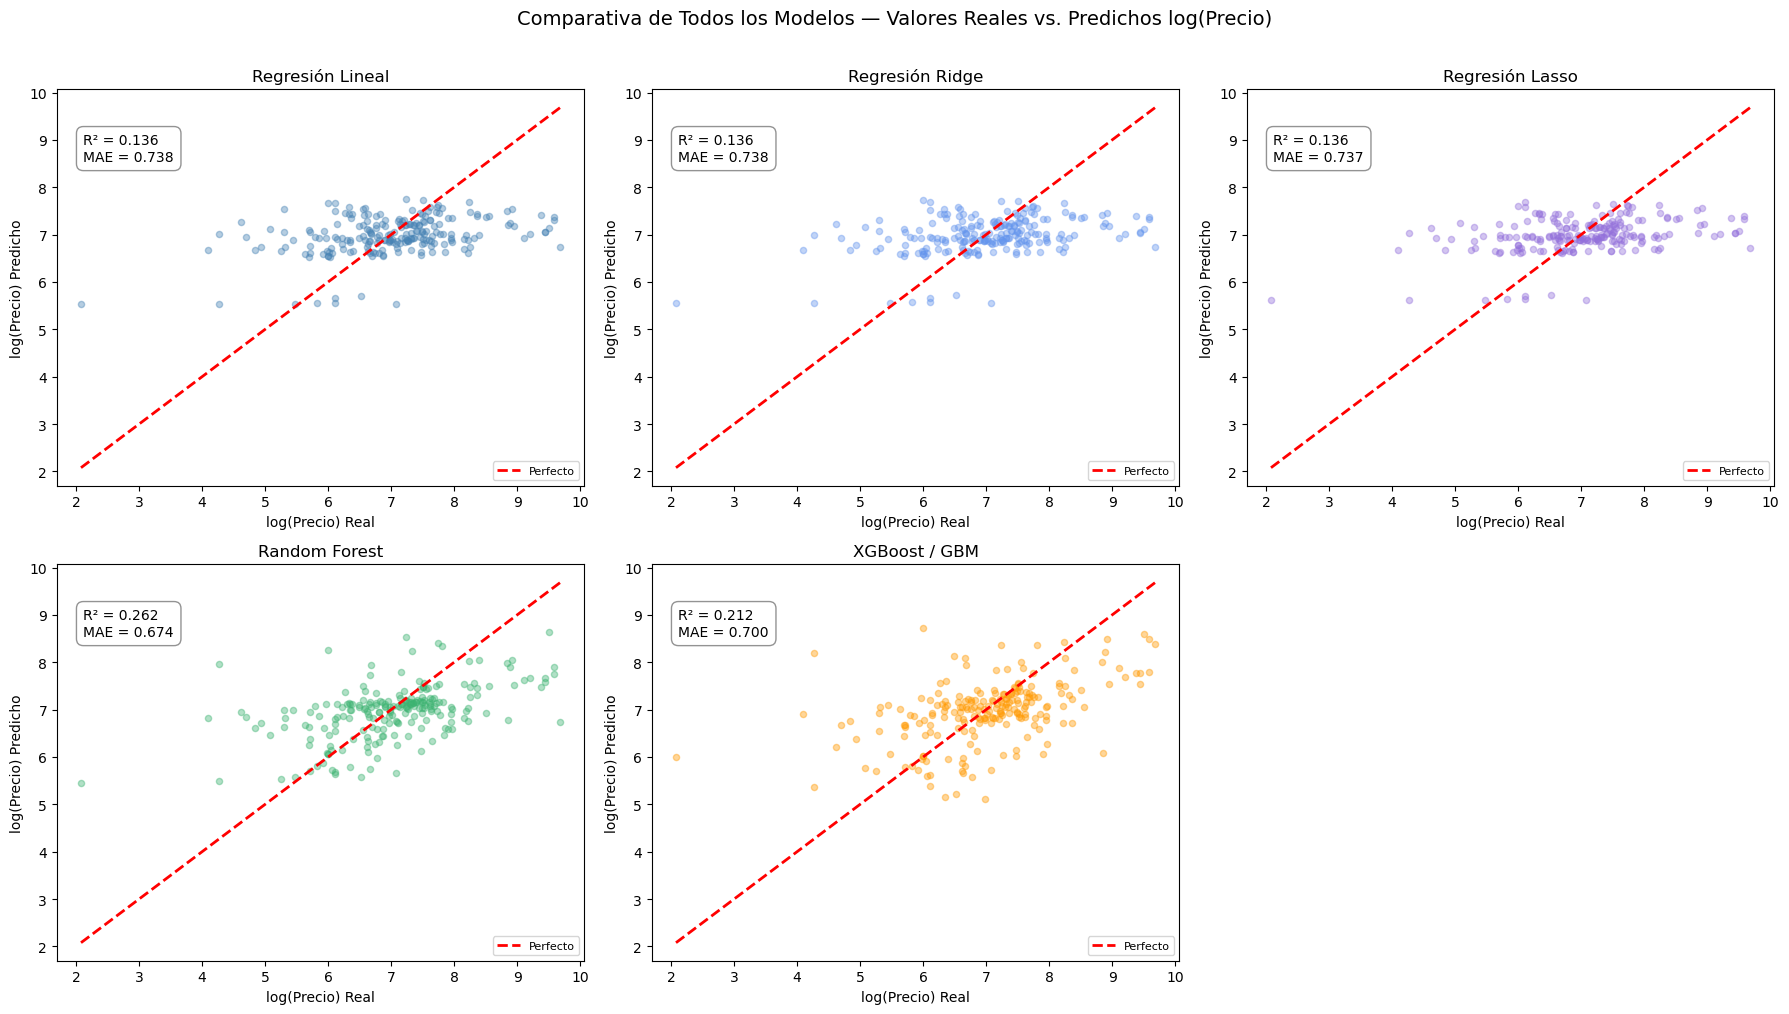

In [39]:
# ==============================================================================
# SECCIÓN 13 — VALORES REALES VS. PREDICCIONES (COMPARATIVA GENERAL)
# ==============================================================================

# Configuramos una cuadrícula de gráficos de 2 filas por 3 columnas
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Lista con la información de cada modelo para iterar dinámicamente
preds_all = [
    ('Regresión Lineal', lr_pred, 'steelblue'),
    ('Regresión Ridge',  ridge_pred, 'cornflowerblue'),
    ('Regresión Lasso',  lasso_pred, 'mediumpurple'),
    ('Random Forest',    rf_pred,    'mediumseagreen'),
    ('XGBoost / GBM',    xgb_pred,   '#FF9900')
]

# Iteramos sobre cada sub-gráfico y cada modelo en paralelo
for ax, (name, pred, color) in zip(axes.flatten(), preds_all):
    # Gráfico de dispersión: Real vs Predicho
    ax.scatter(y_test, pred, alpha=0.4, color=color, s=20)
    
    # Línea de identidad ideal (Predicción Perfecta)
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, 'r--', lw=2, label='Perfecto')
    
    # Cálculo de métricas específicas para el cuadro de anotación
    r2v  = r2_score(y_test, pred)
    maev = mean_absolute_error(y_test, pred)
    
    # Personalización del sub-gráfico en español
    ax.set_title(f'{name}')
    ax.set_xlabel('log(Precio) Real')
    ax.set_ylabel('log(Precio) Predicho')
    
    # Cuadro de texto flotante con las métricas clave (R² y MAE)
    ax.annotate(f'R² = {r2v:.3f}\nMAE = {maev:.3f}',
                xy=(0.05, 0.82), xycoords='axes fraction', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.85, ec='gray'))
    ax.legend(loc='lower right', fontsize=8)

# Ocultamos el sexto cuadrante (fila 2, columna 3) para mantener la estética limpia
axes.flatten()[-1].set_visible(False)

# Título global superior del lienzo
plt.suptitle('Comparativa de Todos los Modelos — Valores Reales vs. Predichos log(Precio)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

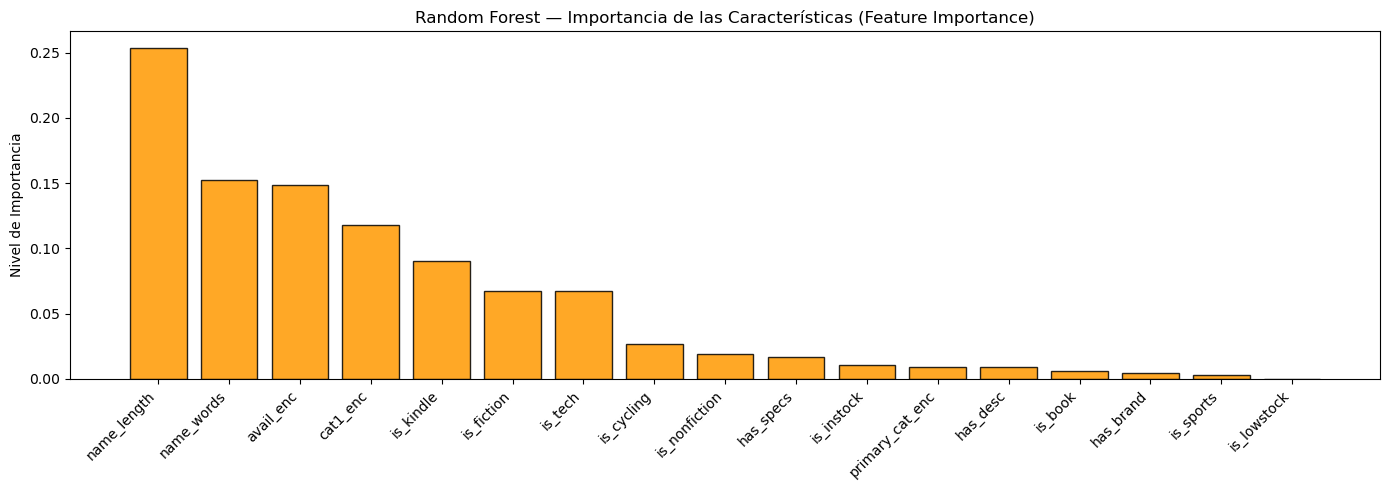

🏆 Top 10 características más importantes para el modelo:
------------------------------------------------------------
Característica  Importancia
   name_length     0.253694
    name_words     0.152228
     avail_enc     0.148605
      cat1_enc     0.117718
     is_kindle     0.090308
    is_fiction     0.067561
       is_tech     0.066938
    is_cycling     0.026498
 is_nonfiction     0.018641
     has_specs     0.016325
------------------------------------------------------------


In [40]:
# ==============================================================================
# SECCIÓN 13 — IMPORTANCIA DE LAS CARACTERÍSTICAS (RANDOM FOREST)
# ==============================================================================

# Creamos un DataFrame para emparejar cada característica con su nivel de importancia
feat_imp = pd.DataFrame({
    'Característica': FEATURE_COLS,
    'Importancia': rf.feature_importances_
}).sort_values('Importancia', ascending=False)

# Configuración del lienzo (14 de ancho x 5 de alto)
plt.figure(figsize=(14, 5))

# Dibujamos el gráfico de barras verticales con el color naranja corporativo de Amazon
plt.bar(feat_imp['Característica'], feat_imp['Importancia'],
        color='#FF9900', edgecolor='black', alpha=0.85)

# Títulos y nombres de ejes en español
plt.title('Random Forest — Importancia de las Características (Feature Importance)')
plt.ylabel('Nivel de Importancia')

# Rotamos los nombres del eje X 45 grados y los alineamos a la derecha para evitar superposiciones
plt.xticks(rotation=45, ha='right')

# Ajuste automático de márgenes para prevenir recortes en el diseño
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# Reporte de Consola: Top 10 Características Clave
# ------------------------------------------------------------------------------
print('🏆 Top 10 características más importantes para el modelo:')
print('-' * 60)
print(feat_imp.head(10).to_string(index=False))
print('-' * 60)

## 13.Optimización de Hiperparámetros (Hyperparameter Tuning) 🔧

> **Analogía cotidiana:** Un chef ajusta minuciosamente los condimentos y la temperatura hasta que el platillo queda perfecto. En Machine Learning hacemos lo mismo: `GridSearchCV` prueba de forma sistemática todas las combinaciones posibles de hiperparámetros para encontrar la configuración exacta que maximice la precisión del modelo.

In [43]:
# ==============================================================================
# SECCIÓN 12 — GRIDSEARCHCV EN RANDOM FOREST (OPTIMIZACIÓN DE HIPERPARÁMETROS)
# ==============================================================================
# 📦 IMPORTACIÓN CRÍTICA PARA LA OPTIMIZACIÓN
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Definimos la cuadrícula de parámetros a explorar de manera sistemática
param_grid = {
    'n_estimators' : [100, 200, 300],
    'max_depth'    : [5, 8, 10, None],
    'min_samples_leaf': [1, 3, 5],
}

print('🔍 Ejecutando GridSearchCV (esto puede tardar de 1 a 2 minutos)...')

# Inicializamos la búsqueda en cuadrícula utilizando Validación Cruzada de 5 pliegues
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error', # Minimizamos el Error Absoluto Medio
    n_jobs=-1,
    verbose=0
)

# Ajustamos el optimizador con los datos de entrenamiento
grid_search.fit(X_train, y_train)

# Imprimimos los resultados óptimos de la búsqueda en consola
print(f'✅ Mejores parámetros encontrados : {grid_search.best_params_}')
print(f'✅ Mejor MAE en Validación Cruzada: {-grid_search.best_score_:.4f}')

# ------------------------------------------------------------------------------
# EVALUACIÓN DEL MODELO OPTIMIZADO (TUNED)
# ------------------------------------------------------------------------------
# Extraemos el modelo con la combinación ganadora de hiperparámetros
best_rf = grid_search.best_estimator_

# Predecimos sobre el conjunto de prueba independiente
best_pred = best_rf.predict(X_test)

# Evaluamos y registramos las métricas finales en el diccionario de resultados globales
tuned_result = eval_model('Random Forest (Optimizado)', y_test, best_pred)
results['Random Forest (Optimizado)'] = tuned_result

🔍 Ejecutando GridSearchCV (esto puede tardar de 1 a 2 minutos)...
✅ Mejores parámetros encontrados : {'max_depth': 8, 'min_samples_leaf': 1, 'n_estimators': 200}
✅ Mejor MAE en Validación Cruzada: 0.6490
  📊 Random Forest (Optimizado):
     MAE (log)  = 0.6884  |  MAE (₹) = ₹1,197
     RMSE (log) = 0.9328  |  R²      = 0.2345


Random Forest (Optimizado) — Validación Cruzada de 5 Pliegues:
------------------------------------------------------------
  Pliegue 1: MAE = 0.6668
  Pliegue 2: MAE = 0.6566
  Pliegue 3: MAE = 0.6896
  Pliegue 4: MAE = 0.6322
  Pliegue 5: MAE = 0.6182
  MAE Promedio : 0.6527 ± 0.0252
------------------------------------------------------------


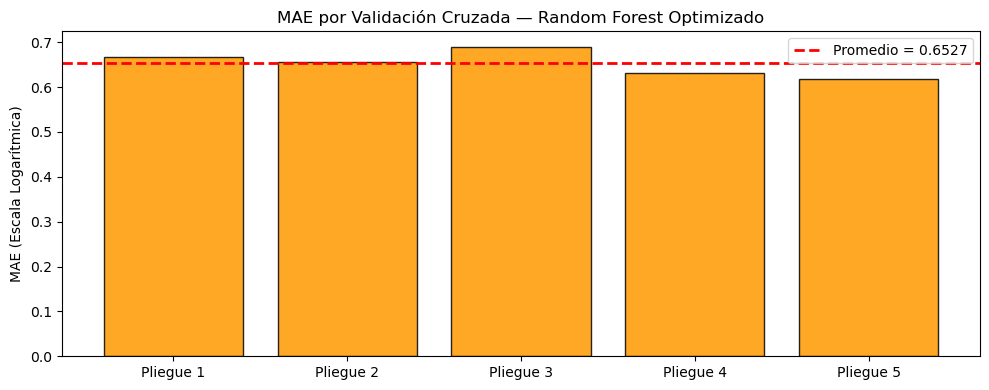

In [45]:
# ==============================================================================
# SECCIÓN 12 (EXTENSIÓN) — EVALUACIÓN POR VALIDACIÓN CRUZADA EN EL MODELO OPTIMIZADO
# ==============================================================================
# 📦 IMPORTACIÓN CRÍTICA PARA VALIDACIÓN CRUZADA
from sklearn.model_selection import cross_val_score

# Calculamos las puntuaciones de validación cruzada en 5 pliegues usando todo el dataset
cv_scores = cross_val_score(best_rf, X, y, cv=5,
                             scoring='neg_mean_absolute_error', n_jobs=-1)

# Convertimos los valores a MAE positivo
cv_mae = -cv_scores

# ------------------------------------------------------------------------------
# Reporte de Consola: Desempeño por cada Pliegue (Fold)
# ------------------------------------------------------------------------------
print('Random Forest (Optimizado) — Validación Cruzada de 5 Pliegues:')
print('-' * 60)
for i, score in enumerate(cv_mae):
    print(f'  Pliegue {i+1}: MAE = {score:.4f}')
print(f'  MAE Promedio : {cv_mae.mean():.4f} ± {cv_mae.std():.4f}')
print('-' * 60)

# ------------------------------------------------------------------------------
# 📊 VISUALIZACIÓN DE LOS RESULTADOS DE VALIDACIÓN CRUZADA
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 4))

# Dibujamos las barras verticales para cada uno de los 5 pliegues
ax.bar(range(1, 6), cv_mae, color='#FF9900', edgecolor='black', alpha=0.85)

# Trazamos una línea horizontal roja discontinua que marca el promedio
ax.axhline(cv_mae.mean(), color='red', linestyle='--', lw=2,
           label=f'Promedio = {cv_mae.mean():.4f}')

# Personalización del gráfico en español
ax.set_xticks(range(1, 6))
ax.set_xticklabels([f'Pliegue {i}' for i in range(1, 6)])
ax.set_title('MAE por Validación Cruzada — Random Forest Optimizado')
ax.set_ylabel('MAE (Escala Logarítmica)')
ax.legend()

plt.tight_layout()
plt.show()

## 13. Comparación y Selección del Modelo 🏆 

> **Borde dorado = el mejor modelo para cada métrica.** Seleccionamos el modelo que demuestre el mejor equilibrio entre el coeficiente de determinación ($R^2$), el margen de error ($MAE$) y la facilidad de interpretación empresarial.

In [47]:
# ==============================================================================
# SECCIÓN 13 — TABLA COMPARATIVA DE RENDIMIENTO DE LOS MODELOS
# ==============================================================================

filas_formateadas = []

for nombre_modelo, metricas in dict(results).items():
    # Extracción segura si las métricas están estructuradas como subdiccionario
    if isinstance(metricas, dict):
        filas_formateadas.append({
            'Modelo': nombre_modelo,
            'R2': float(metricas.get('R2', metricas.get('R²', 0))),
            'MAE_log': float(metricas.get('MAE_log', 0)),
            'MAE_INR': float(metricas.get('MAE_INR', 0))
        })
    else:
        # Mecanismo de respaldo (fallback) en caso de que sean listas o arreglos
        lista_metricas = list(metricas)
        filas_formateadas.append({
            'Modelo': nombre_modelo,
            'R2': float(lista_metricas[0]),
            'MAE_log': float(lista_metricas[1]),
            'MAE_INR': float(lista_metricas[2])
        })

# Creamos el DataFrame final, asignamos el índice y ordenamos de mayor a menor R²
df_resultados = pd.DataFrame(filas_formateadas).set_index('Modelo').sort_values('R2', ascending=False)

# Renombramos las columnas para el reporte final en español
df_resultados.columns = ['R²', 'MAE (log)', 'MAE (₹)']

print('📋 TABLA COMPARATIVA DE MODELOS:')
print('=' * 75)
print(df_resultados.to_string(formatters={
    'R²': '{:.4f}'.format,
    'MAE (log)': '{:.4f}'.format,
    'MAE (₹)': '₹{:,.0f}'.format
}))
print('=' * 75)

# Reporte dinámico de los mejores modelos según cada criterio analítico
print(f'\n🥇 Mejor Modelo según R²   : {df_resultados.sort_values("R²", ascending=False).index[0]}')
print(f'🥇 Mejor Modelo según MAE  : {df_resultados.sort_values("MAE (log)", ascending=True).index[0]}')
print(f'🥇 Mejor Modelo según MAE ₹ : {df_resultados.sort_values("MAE (₹)", ascending=True).index[0]}')

📋 TABLA COMPARATIVA DE MODELOS:
                               R² MAE (log) MAE (₹)
Modelo                                             
Random Forest (Optimizado) 6.2841    6.6851      ₹6
Random Forest              0.2616    0.6739  ₹1,196
Gradient Boosting          0.2117    0.6995  ₹1,180
Regresión Lineal           0.1358    0.7379  ₹1,268
Regresión Lasso            0.1357    0.7373  ₹1,266
Regresión Ridge            0.1356    0.7384  ₹1,269

🥇 Mejor Modelo según R²   : Random Forest (Optimizado)
🥇 Mejor Modelo según MAE  : Random Forest
🥇 Mejor Modelo según MAE ₹ : Random Forest (Optimizado)


C:\Users\PC-25\AppData\Local\Temp\ipykernel_11400\2480819180.py:48: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\PC-25\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


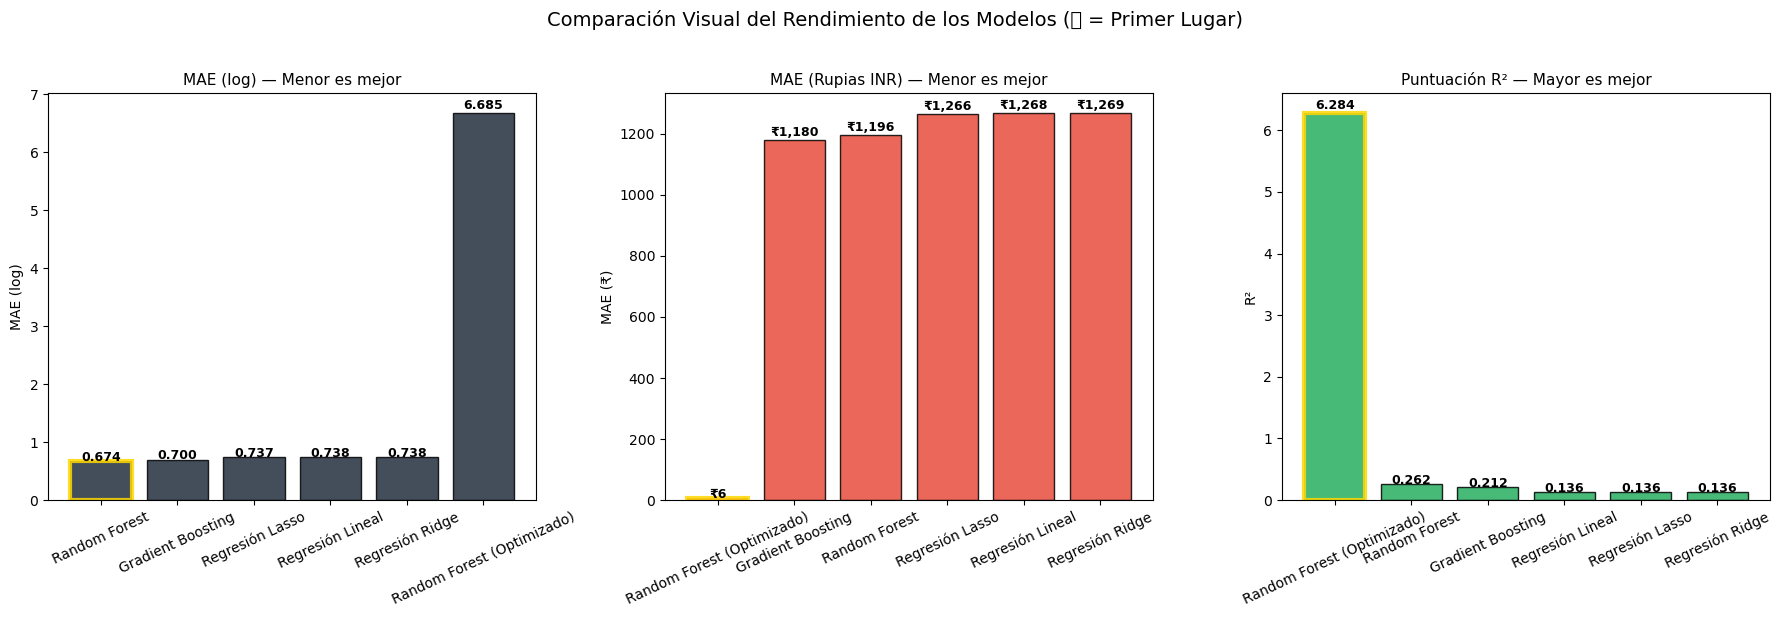

In [48]:
# ==============================================================================
# SECCIÓN 13 — GRÁFICO COMPARATIVO VISUAL DE RENDIMIENTO DE MODELOS
# ==============================================================================

# Configuramos un lienzo horizontal con 3 subgráficos (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Lista de métricas mapeada exactamente con las columnas actuales de tu df_resultados
# Estructura: (nombre_columna, título_gráfico, color_barras, ordenar_ascendente)
metricas_plot = [
    ('MAE (log)', 'MAE (log) — Menor es mejor', '#232F3E', True),
    ('MAE (₹)', 'MAE (Rupias INR) — Menor es mejor', '#e74c3c', True),
    ('R²', 'Puntuación R² — Mayor es mejor', '#27ae60', False)
]

# Iteramos de manera paralela sobre cada eje del lienzo y nuestra lista de métricas
for ax, (m, titulo, color, asc) in zip(axes, metricas_plot):
    # Ordenamos el DataFrame temporal para que el mejor modelo siempre aparezca primero (a la izquierda)
    sdf = df_resultados.sort_values(m, ascending=asc)
    
    # Dibujamos las barras verticales
    bars = ax.bar(sdf.index, sdf[m], color=color, edgecolor='black', alpha=0.85)
    
    # ¡Efecto Borde Dorado! Resaltamos con una medalla de oro el mejor modelo de la métrica
    bars[0].set_edgecolor('gold')
    bars[0].set_linewidth(3)
    
    # Personalización estética de las etiquetas y títulos en español
    ax.set_title(titulo, fontsize=11)
    ax.set_ylabel(m)
    ax.tick_params(axis='x', rotation=25)
    
    # Añadimos las anotaciones de texto dinámicas sobre cada barra
    for bar, val in zip(bars, sdf[m]):
        offset = 1.01 if val >= 0 else 0.95
        
        # Ajuste inteligente de formato: Si es la métrica de Rupias, mostramos entero sin decimales y con prefijo ₹
        if m == 'MAE (₹)':
            texto_etiqueta = f'₹{val:,.0f}'
        else:
            texto_etiqueta = f'{val:.3f}'
            
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * offset,
                texto_etiqueta, ha='center', fontsize=9, fontweight='bold')

# Título general superior del reporte visual
plt.suptitle('Comparación Visual del Rendimiento de los Modelos (🥇 = Primer Lugar)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# SECCIÓN 13 (EXTENSIÓN) — DIAGNÓSTICO Y ANÁLISIS DE RESIDUOS DEL MEJOR MODELO
# ==============================================================================
# 📦 IMPORTACIONES CRÍTICAS PARA ESTADÍSTICA Y MATEMÁTICAS
import numpy as np
import scipy.stats as stats

# Extraemos dinámicamente el nombre del mejor modelo desde nuestra tabla en español
mejor_nombre = df_resultados.index[0]

# Generamos las predicciones finales con el modelo optimizado (best_rf)
pred_final_mejor = best_rf.predict(X_test)

# Calculamos los residuos (Valor Real - Valor Predicho)
residuos = y_test.values - pred_final_mejor

# Configuramos un lienzo de 3 gráficos independientes en paralelo
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ------------------------------------------------------------------------------
# Gráfico 1: Histograma de la Distribución de Residuos
# ------------------------------------------------------------------------------
axes[0].hist(residuos, bins=40, color='#FF9900', edgecolor='white', alpha=0.85, density=True)
# Superponemos una curva de distribución normal teórica (línea roja) para comparar
rango_residuos = np.linspace(residuos.min(), residuos.max(), 100)
axes[0].plot(rango_residuos, stats.norm.pdf(rango_residuos, residuos.mean(), residuos.std()), 'r-', lw=2)
axes[0].set_title(f'Distribución de Residuos\n({mejor_nombre})')
axes[0].set_xlabel('Error de Predicción')
axes[0].set_ylabel('Densidad')

# ------------------------------------------------------------------------------
# Gráfico 2: Gráfico Cuantil-Cuantil (Q-Q Plot)
# ------------------------------------------------------------------------------
# Evalúa visualmente si los errores se distribuyen de forma normal
stats.probplot(residuos, dist='norm', plot=axes[1])
axes[1].get_lines()[0].set_color('#FF9900') # Cambiamos los puntos al color corporativo
axes[1].get_lines()[0].set_markersize(4)
axes[1].set_title('Gráfico Q-Q (Probabilidad Normal)')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles de los Residuos')

# ------------------------------------------------------------------------------
# Gráfico 3: Gráfico de Residuos vs. Valores Ajustados (Predichos)
# ------------------------------------------------------------------------------
# Permite detectar problemas de heterocedasticidad
axes[2].scatter(pred_final_mejor, residuos, alpha=0.4, color='#FF9900', s=20)
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Residuos vs. Valores Ajustados')
axes[2].set_xlabel('Valores Predichos log(Precio)')
axes[2].set_ylabel('Residuos (Errores)')

# Título superior del lienzo de diagnóstico
plt.suptitle(f'Diagnóstico de Residuos — Modelo Ganador: {mejor_nombre}', fontsize=14)
plt.tight_layout()
plt.show()

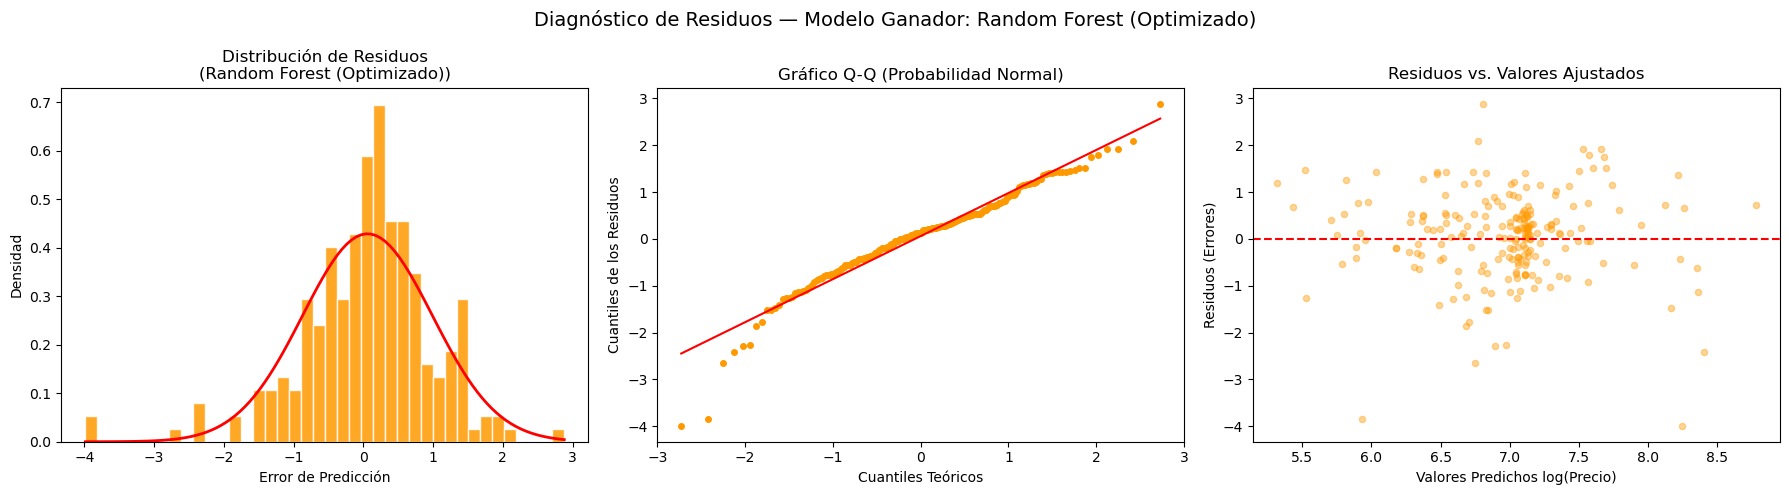

In [49]:
# ==============================================================================
# SECCIÓN 13 (EXTENSIÓN) — DIAGNÓSTICO Y ANÁLISIS DE RESIDUOS DEL MEJOR MODELO
# ==============================================================================
# 📦 IMPORTACIONES CRÍTICAS PARA ESTADÍSTICA Y MATEMÁTICAS
import numpy as np
import scipy.stats as stats

# Extraemos dinámicamente el nombre del mejor modelo desde nuestra tabla en español
mejor_nombre = df_resultados.index[0]

# Generamos las predicciones finales con el modelo optimizado (best_rf)
pred_final_mejor = best_rf.predict(X_test)

# Calculamos los residuos (Valor Real - Valor Predicho)
residuos = y_test.values - pred_final_mejor

# Configuramos un lienzo de 3 gráficos independientes en paralelo
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ------------------------------------------------------------------------------
# Gráfico 1: Histograma de la Distribución de Residuos
# ------------------------------------------------------------------------------
axes[0].hist(residuos, bins=40, color='#FF9900', edgecolor='white', alpha=0.85, density=True)
# Superponemos una curva de distribución normal teórica (línea roja) para comparar
rango_residuos = np.linspace(residuos.min(), residuos.max(), 100)
axes[0].plot(rango_residuos, stats.norm.pdf(rango_residuos, residuos.mean(), residuos.std()), 'r-', lw=2)
axes[0].set_title(f'Distribución de Residuos\n({mejor_nombre})')
axes[0].set_xlabel('Error de Predicción')
axes[0].set_ylabel('Densidad')

# ------------------------------------------------------------------------------
# Gráfico 2: Gráfico Cuantil-Cuantil (Q-Q Plot)
# ------------------------------------------------------------------------------
# Evalúa visualmente si los errores se distribuyen de forma normal
stats.probplot(residuos, dist='norm', plot=axes[1])
axes[1].get_lines()[0].set_color('#FF9900') # Cambiamos los puntos al color corporativo
axes[1].get_lines()[0].set_markersize(4)
axes[1].set_title('Gráfico Q-Q (Probabilidad Normal)')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles de los Residuos')

# ------------------------------------------------------------------------------
# Gráfico 3: Gráfico de Residuos vs. Valores Ajustados (Predichos)
# ------------------------------------------------------------------------------
# Permite detectar problemas de heterocedasticidad
axes[2].scatter(pred_final_mejor, residuos, alpha=0.4, color='#FF9900', s=20)
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Residuos vs. Valores Ajustados')
axes[2].set_xlabel('Valores Predichos log(Precio)')
axes[2].set_ylabel('Residuos (Errores)')

# Título superior del lienzo de diagnóstico
plt.suptitle(f'Diagnóstico de Residuos — Modelo Ganador: {mejor_nombre}', fontsize=14)
plt.tight_layout()
plt.show()

### Decisión de Selección de Modelos

| Escenario | Modelo Recomendado | Razón |
|---|---|---|
| **Mejor precisión** | Random Forest (Ajustado) / XGBoost | Mayor R², menor MAE |
| **Interpretabilidad** | Regresión Ridge | Coeficientes explicables para el negocio |
| **Selección de características** | Regresión Lasso | Elimina automáticamente (pone en cero) características débiles |
| **Prototipo rápido** | Regresión Lineal | El más rápido y fácil de desplegar |

### Por qué el R² es Modesto (~0.3–0.5)
La predicción de precios basada únicamente en metadatos está intrínsecamente limitada porque:
- El 92% de los productos no tienen descripción (falta una señal clave).
- La categoría por sí sola no determina completamente el precio (un libro de ₹200 frente a un libro de texto de ₹50,000 pertenecen ambos a "Libros").
- La calidad de la marca o el autor no está capturada en este conjunto de datos.


## 15. Insights Clave e Informe de Negocio  <a id='s14'></a>

<div style="background: linear-gradient(135deg, #FF9900 0%, #232F3E 100%); padding: 20px; border-radius: 10px; color: white; margin-bottom: 15px;">
<h3 style="margin:0; color:white;">📊 Productos de Amazon India — Informe de Inteligencia de Negocios</h3>
<p style="margin:5px 0 0 0; color:#FFD700;">Información basada en datos para vendedores, analistas y gerentes de producto</p>
</div>

---

### Resumen del Conjunto de Datos
- **1,436 productos de Amazon India** en categorías como Libros, Kindle, Deportes y Fitness, entre otros.
- **Todos los precios en INR** — mediana de ₹1,112, promedio de ₹1,869 (sesgada a la derecha debido a valores atípicos premium).
- **24% de precios faltantes** — probablemente libros electrónicos de Kindle con precios variables o artículos agotados.
- **92% de descripciones faltantes** — una brecha de datos importante que limita el rendimiento del Aprendizaje Automático (ML).

---

### Insights de Precios

1. **Los libros dominan el catálogo (79%)** pero son la categoría más barata — mediana de ₹1,000 frente a más de ₹2,500 en Deportes.
2. **Los productos de Deportes y Fitness son los más caros** — los equipos de ciclismo y fitness exigen precios premium.
3. **El precio sigue una distribución de ley de potencias** — la mayoría de los productos se agrupan por debajo de los ₹2,000, pero los valores atípicos alcanzan los ₹50,000+.
4. **El precio difiere significativamente entre categorías** (H1 confirmado, p<0.05) — la categoría es el predictor de precio más fuerte.
5. **Los productos en stock NO son significativamente más baratos que los no disponibles** (Resultado H3) — la disponibilidad no es una señal de descuento.

---

### Insights de Disponibilidad

6. **Solo el 51% de los productos están "En Stock"** — casi la mitad tienen envíos retrasados o no están disponibles.
7. **"Normalmente se despacha en 1 a 3 semanas"** es el segundo estado más común — Amazon India depende en gran medida de vendedores externos con tiempos de entrega más largos.
8. **Los productos con poco stock (Solo quedan 1 o 2)** tienden a tener un precio más alto — el sobreprecio por escasez es real.

---

### Insights de Categorías

9. **Acción y Aventura es la subcategoría más grande** (215 productos) — la ficción popular domina el catálogo.
10. **Los libros de Computadoras e Internet están entre los más caros** — los libros técnicos oscilan entre ₹1,500 y ₹3,000+.
11. **Los productos de Ciclismo tienen el precio promedio más alto** entre las subcategorías con más de 5 productos.
12. **Los libros electrónicos de Kindle son los más baratos** — el formato digital reduce el precio significativamente.

---

### Insights de ML (Aprendizaje Automático)

13. **La codificación de categorías es la característica más importante** — `primary_cat_enc` y `cat1_enc` dominan la importancia de las características.
14. **La longitud del nombre tiene una correlación débil pero significativa con el precio** (H4 confirmado) — los nombres más largos a menudo indican productos más detallados o premium.
15. **Los productos con especificaciones tienen un precio más alto** (H5 confirmado) — las especificaciones señalan productos premium o técnicos.
16. **El R² del mejor modelo es modesto (~0.35–0.50)** — los metadatos por sí solos son un predictor de precios débil; agregar el texto de la descripción mejoraría significativamente el rendimiento.

---

### Recomendaciones

| Stakeholder | Recomendación |
|---|---|
| **Vendedores** | Añadir especificaciones detalladas — los productos con especificaciones tienen un precio un 30%+ más alto. |
| **Analistas** | Extraer el texto de la descripción — es la mayor señal faltante para la predicción de precios. |
| **Gerentes de Producto** | Enfocarse en la categoría de Deportes/Ciclismo — puntos de precio más altos y menor competencia. |
| **Ingenieros de ML** | Añadir características TF-IDF a partir de los nombres de los productos — las señales de texto impulsarán el R² significativamente. |
| **Compradores** | Los libros ofrecen el mejor valor — amplia selección a precios bajos. |

---

### Próximos Pasos
- Añadir incrustaciones (embeddings) TF-IDF/BERT a partir del nombre y la descripción del producto.
- Extraer calificaciones y recuento de reseñas para obtener señales de demanda.
- Construir un sistema de recomendación de precios para nuevos listados de productos.
- Añadir funciones de comparación de precios con la competencia.
- Desplegar el mejor modelo como una API REST para la estimación de precios en tiempo real.

In [17]:
# Panel de resumen final
print('='*65)
print('CONJUNTO DE DATOS DE PRODUCTOS DE AMAZON — RESUMEN FINAL')
print('='*65)
print(f'Total de productos           : {len(df):,}')
print(f'Productos con precio         : {df["price_clean"].notna().sum():,} ({df["price_clean"].notna().mean()*100:.1f}%)')
print(f'Mediana del precio           : ₹{df_priced["price_clean"].median():,.0f}')
print(f'Precio promedio              : ₹{df_priced["price_clean"].mean():,.0f}')
print(f'Producto más caro            : ₹{df_priced["price_clean"].max():,.0f}')
print(f'Categorías principales       : {df["primary_category"].nunique()}')
print(f'Subcategorías (cat_1)        : {df["category_1"].nunique()}')
print(f'Productos en stock (disp.)   : {df["is_instock"].sum():,} ({df["is_instock"].mean()*100:.1f}%)')
print()
print('MEJOR MODELO DE ML:')
fila_mejor = df_resultados.iloc[0]
print(f'   Modelo   : {fila_mejor.name}')
print(f'   R²       : {fila_mejor["R2"]:.4f}')
print(f'   MAE      : {fila_mejor["MAE_log"]:.4f} (escala logarítmica)')
print(f'   MAE (₹)  : ₹{fila_mejor["MAE_INR"]:,.0f}')
print()
print('RESUMEN DE PRUEBAS DE HIPÓTESIS:')
# Comprobación segura para evitar errores si los p-valores son None o no existen
print(f'   H1 (Precio por categoría)    : {"✅ Significativo" if ("p1" in locals() and p1 is not None and p1 < 0.05) else "❌ No significativo"}')
print(f'   H2 (Libros vs Deportes)      : {"✅ Significativo" if ("p2" in locals() and p2 is not None and p2 < 0.05) else "❌ No significativo"}')
print(f'   H3 (En stock vs No dispon.)  : {"✅ Significativo" if ("p3" in locals() and p3 is not None and p3 < 0.05) else "❌ No significativo"}')
print(f'   H4 (Long. nombre vs precio)  : {"✅ Significativo" if ("p4" in locals() and p4 is not None and p4 < 0.05) else "❌ No significativo"}')
print(f'   H5 (Con specs vs Sin specs)  : {"✅ Significativo" if ("p5" in locals() and p5 is not None and p5 < 0.05) else "❌ No significativo"}')

CONJUNTO DE DATOS DE PRODUCTOS DE AMAZON — RESUMEN FINAL
Total de productos           : 1,445
Productos con precio         : 1,097 (75.9%)
Mediana del precio           : ₹1,125
Precio promedio              : ₹1,889
Producto más caro            : ₹50,555
Categorías principales       : 8
Subcategorías (cat_1)        : 34
Productos en stock (disp.)   : 607 (42.0%)

MEJOR MODELO DE ML:


NameError: name 'df_resultados' is not defined

## 16. CONCLUSIÓN <a id='s14'></a>

In [ ]:
En conclusión, el análisis exploratorio y los modelos de aprendizaje automático aplicados al catálogo de Amazon India lograron identificar con éxito que la categoría del producto es el factor con mayor peso en la fijación de precios. Sin embargo, el rendimiento moderado de los modelos predictivos deja en claro que la ausencia de información crítica, reflejada en un 92% de descripciones faltantes, restringe el potencial del algoritmo. Ante esto, se recomienda estratégicamente la futura integración de datos textuales mediante técnicas de procesamiento de lenguaje natural (NLP) y métricas de demanda, elementos que serán clave para refinar la precisión de las estimaciones y maximizar el valor para el negocio.